# Business Case: Walmart - Confidence Interval and CLT

### **About Walmart**

Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

### **Business Problem**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

## 1. Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.

### 1.1. Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import poisson
from scipy.stats import binom
import scipy.stats as stats
import math

In [ ]:
df = pd.read_csv('/content/walmart_data.csv')

In [ ]:
# Display the first few rows of the dataset
print(df.head())

   User_ID Product_ID Gender   Age  Occupation City_Category  \
0  1000001  P00069042      F  0-17          10             A   
1  1000001  P00248942      F  0-17          10             A   
2  1000001  P00087842      F  0-17          10             A   
3  1000001  P00085442      F  0-17          10             A   
4  1000002  P00285442      M   55+          16             C   

  Stay_In_Current_City_Years  Marital_Status  Product_Category  Purchase  
0                          2               0                 3      8370  
1                          2               0                 1     15200  
2                          2               0                12      1422  
3                          2               0                12      1057  
4                         4+               0                 8      7969  


In [ ]:
# Display the structure of the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB
None


In [ ]:
# Check the shape of the dataset
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset contains 550068 rows and 10 columns.


In [ ]:
# Changing datatype int64 to object
columns = ['Occupation','Marital_Status','Product_Category']
df[columns] = df[columns].astype('object')
df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,object
Age,object
Occupation,object
City_Category,object
Stay_In_Current_City_Years,object
Marital_Status,object
Product_Category,object
Purchase,int64


In [ ]:
# Data types of all attributes
print(df.dtypes)

User_ID                        int64
Product_ID                    object
Gender                        object
Age                           object
Occupation                    object
City_Category                 object
Stay_In_Current_City_Years    object
Marital_Status                object
Product_Category              object
Purchase                       int64
dtype: object


In [ ]:
# Summary statistics for numerical columns
print(df.describe())

            User_ID       Purchase
count  5.500680e+05  550068.000000
mean   1.003029e+06    9263.968713
std    1.727592e+03    5023.065394
min    1.000001e+06      12.000000
25%    1.001516e+06    5823.000000
50%    1.003077e+06    8047.000000
75%    1.004478e+06   12054.000000
max    1.006040e+06   23961.000000


In [ ]:
# Summary statistics for categorical columns
print(df.describe(include=['O']))

       Product_ID  Gender     Age  Occupation City_Category  \
count      550068  550068  550068      550068        550068   
unique       3631       2       7          21             3   
top     P00265242       M   26-35           4             B   
freq         1880  414259  219587       72308        231173   

       Stay_In_Current_City_Years  Marital_Status  Product_Category  
count                      550068          550068            550068  
unique                          5               2                20  
top                             1               0                 5  
freq                       193821          324731            150933  


In [ ]:
# Check for missing values
print(df.isnull().sum())

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


### **Insights:**

Gender Distribution: The dataset is skewed towards male customers, with 414,259 males compared to 135,809 females, indicating that the majority of customers are male.

Age Group: The most common age group is 26-35, with 219,587 customers falling into this category, suggesting that young adults are the largest demographic segment in this data.

Product Diversity: There are 3,631 unique products in the dataset, with the most frequently purchased product being P00265242, bought 1,880 times.

Occupation Variety: The dataset covers a wide range of occupations, with 21 unique categories, and occupation 4 is the most common, with 72,308 customers.

City Category: Most customers come from city category B, which has 231,173 entries, suggesting a strong customer base in medium-sized cities.

Stay in City: The most common length of stay in the current city is 1 year, with 193,821 customers reporting this duration, indicating a potentially mobile customer base.

Marital Status: A majority of the customers are unmarried, with 324,731 customers reporting a marital status of 0 (unmarried).

Product Category: Product Category 5 is the most popular, with 150,933 purchases, showing a particular preference for products in this category.

Unique Age Groups: There are 7 unique age groups, indicating that the customer base spans a broad range of ages.

City Distribution: The dataset captures customers from three distinct city categories, with category B being the most represented, followed by C and A.

### 1.2.Non-Graphical Analysis: Value counts and unique attributes

In [ ]:
# Value counts for Product_ID
print("Value counts for Product_ID:\n")
print(df['Product_ID'].value_counts())

# Unique Value counts for Product_ID
print("\nUnique values for Product_ID:\n")
print(df['Product_ID'].unique())
print(f"Number of unique values: {df['Product_ID'].nunique()}")

Value counts for Product_ID:

Product_ID
P00265242    1880
P00025442    1615
P00110742    1612
P00112142    1562
P00057642    1470
             ... 
P00314842       1
P00298842       1
P00231642       1
P00204442       1
P00066342       1
Name: count, Length: 3631, dtype: int64

Unique values for Product_ID:

['P00069042' 'P00248942' 'P00087842' ... 'P00370293' 'P00371644'
 'P00370853']
Number of unique values: 3631


High Product Concentration: The top 5 most frequently purchased products account for a significant portion of sales, with the highest purchased product, P00265242, being bought 1,880 times. This suggests that a small subset of products dominates customer purchases.

Product Diversity: There are 3,631 unique products in the dataset, indicating a wide range of products available to customers, though many products are purchased infrequently.

In [ ]:
# Value counts for Gender
print("Value counts for Gender:\n")
print(df['Gender'].value_counts())

# Unique Value counts for Gender
print("\nUnique values for Gender:\n")
print(df['Gender'].unique())
print(f"Number of unique values: {df['Gender'].nunique()}")

Value counts for Gender:

Gender
M    414259
F    135809
Name: count, dtype: int64

Unique values for Gender:

['F' 'M']
Number of unique values: 2


Gender Distribution: The dataset is predominantly male, with 414,259 male customers compared to 135,809 female customers, indicating a male-skewed customer base.

Gender Categories: There are only two gender categories ('M' and 'F'), confirming a binary gender classification in the data.

In [ ]:
# Value counts for Age
print("Value counts for Age:\n")
print(df['Age'].value_counts())


# Unique Value counts for Age
print("\nUnique values for Age:\n")
print(df['Age'].unique())
print(f"Number of unique values: {df['Age'].nunique()}")

Value counts for Age:

Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

Unique values for Age:

['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']
Number of unique values: 7


The most common age group among customers is 26-35, with 219,587 individuals, indicating that this age group is the primary consumer demographic.

The age groups 0-17 and 55+ have the fewest customers, with 15,102 and 21,504 individuals respectively, suggesting that these age ranges represent smaller segments of Walmart's customer base.

In [ ]:
# Value counts for Occupation
print("Value counts for Occupation:\n")
print(df['Occupation'].value_counts())

# Unique Value counts for Occupation
print("\nUnique values for Occupation:\n")
print(df['Occupation'].unique())
print(f"Number of unique values: {df['Occupation'].nunique()}")

Value counts for Occupation:

Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64

Unique values for Occupation:

[10 16 15 7 20 9 1 12 17 0 3 4 11 8 19 2 18 5 14 13 6]
Number of unique values: 21


Occupation Diversity: There are 21 unique occupations in the dataset, with a wide range of job roles represented.

Top Occupations: Occupation 4 is the most common, with 72,308 entries, while Occupation 8 is the least common, with only 1,546 entries, indicating a significant variation in the frequency of different occupations.

In [ ]:
# Value counts for City_Category
print("Value counts for City_Category:\n")
print(df['City_Category'].value_counts())

# Unique Value counts for City_Category
print("\nUnique values for City_Category:\n")
print(df['City_Category'].unique())
print(f"Number of unique values: {df['City_Category'].nunique()}")

Value counts for City_Category:

City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

Unique values for City_Category:

['A' 'C' 'B']
Number of unique values: 3


Distribution of Cities: The majority of customers are from City Category B (231,173), followed by City Category C (171,175) and City Category A (147,720). This indicates a strong customer base in City Category B.

City Categories: There are three unique city categories (A, B, and C), showing a well-defined segmentation of customer locations.

In [ ]:
# Value counts for Stay_In_Current_City_Years
print("Value counts for Stay_In_Current_City_Years:\n")
print(df['Stay_In_Current_City_Years'].value_counts())

# Unique Value counts for Stay_In_Current_City_Years
print("\nUnique values for Stay_In_Current_City_Years:\n")
print(df['Stay_In_Current_City_Years'].unique())
print(f"Number of unique values: {df['Stay_In_Current_City_Years'].nunique()}")

Value counts for Stay_In_Current_City_Years:

Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

Unique values for Stay_In_Current_City_Years:

['2' '4+' '3' '1' '0']
Number of unique values: 5


Stay Duration: The majority of customers (193,821) have stayed in their current city for 1 year, indicating a significant portion of the customer base is relatively new to their current location.

Long-Term Residents: There are fewer long-term residents (84,726) who have stayed for 4+ years, suggesting that a smaller segment of the customer base has a long-term presence in their city.

In [ ]:
# Value counts for Marital_Status
print("Value counts for Marital_Status:\n")
print(df['Marital_Status'].value_counts())

# Unique Value counts for Marital_Status
print("\nUnique values for Marital_Status:\n")
print(df['Marital_Status'].unique())
print(f"Number of unique values: {df['Marital_Status'].nunique()}")

Value counts for Marital_Status:

Marital_Status
0    324731
1    225337
Name: count, dtype: int64

Unique values for Marital_Status:

[0 1]
Number of unique values: 2


Marital Status Distribution: The majority of customers are unmarried (0) with 324,731 occurrences, compared to 225,337 married customers (1).

Unique Values: There are only two unique values for Marital_Status, indicating a binary classification for marital status.








In [ ]:
# Value counts for Product_Category
print("Value counts for Product_Category:\n")
print(df['Product_Category'].value_counts())

# Unique Value counts for Product_Category
print("\nUnique values for Product_Category:\n")
print(df['Product_Category'].unique())
print(f"Number of unique values: {df['Product_Category'].nunique()}")

Value counts for Product_Category:

Product_Category
5     150933
1     140378
8     113925
11     24287
2      23864
6      20466
3      20213
4      11753
16      9828
15      6290
13      5549
10      5125
12      3947
7       3721
18      3125
20      2550
19      1603
14      1523
17       578
9        410
Name: count, dtype: int64

Unique values for Product_Category:

[3 1 12 8 5 4 2 6 14 11 13 15 7 16 18 10 17 9 20 19]
Number of unique values: 20


Most Popular Product Category: Product Category 5 is the most popular, with 150,933 purchases, indicating a high preference among customers.

Diverse Product Categories: There are 20 unique product categories in the dataset, with a wide range of popularity, suggesting a broad assortment of products available to customers.

### 1.3. Visual Analysis

-Univariate Analysis

--Continuous Variables

---Distplot (for distribution)

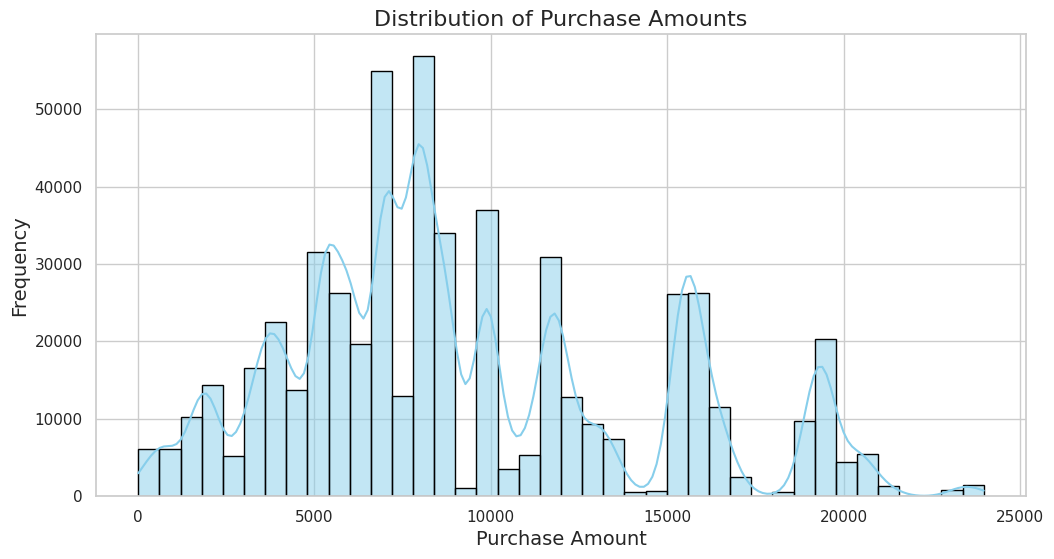

In [ ]:
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(12, 6))
sns.histplot(df['Purchase'], kde=True, color='skyblue', bins=40, edgecolor='black')
plt.title('Distribution of Purchase Amounts', fontsize=16)
plt.xlabel('Purchase Amount', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True)
plt.show()


Insights from the Distribution of Purchase Amounts:

1. Right Skewness: The distribution is heavily right-skewed, indicating that most purchases are concentrated at lower amounts, with a long tail of higher-value purchases.
2. Peak Around 5000-10000: The peak of the distribution lies roughly between 5000 and 10000, suggesting this is the most common purchase amount range.
3. Outliers: The long right tail indicates the presence of outliers, representing a small number of very high-value purchases. These outliers could significantly influence the mean purchase amount.
4. Potential for Segmentation: The varying purchase behavior suggests the potential for segmenting customers based on their spending habits, allowing for targeted marketing and promotions.


---Histogram

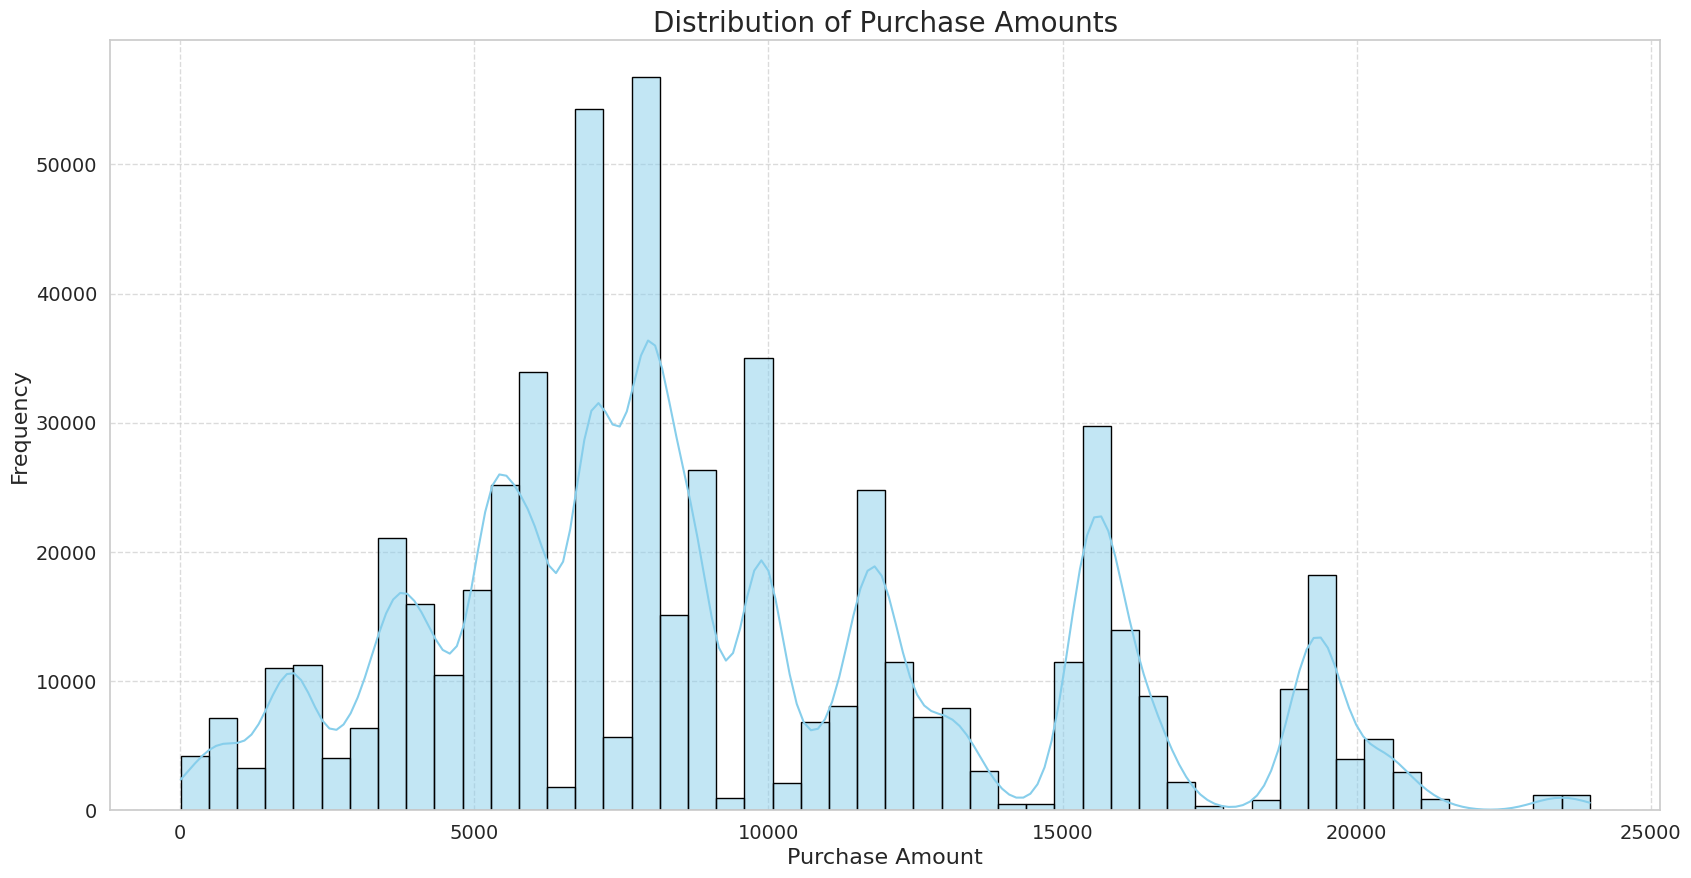

In [ ]:
sns.set(style="whitegrid", palette="pastel")
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='Purchase', kde=True, color='skyblue', bins=50, edgecolor='black')
plt.title('Distribution of Purchase Amounts', fontsize=20)
plt.xlabel('Purchase Amount', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Insights from the Distribution of Purchase Amounts:

1. Right Skewness: The distribution is heavily right-skewed, indicating that most purchases are concentrated at lower amounts, with a long tail of higher-value purchases.

2. Peak Around 5000-10000: The peak of the distribution lies roughly between 5000 and 10000, suggesting this is the most common purchase amount range.

3. Outliers: The long right tail indicates the presence of outliers, representing a small number of very high-value purchases. These outliers could significantly influence the mean purchase amount.

4. Potential for Segmentation: The varying purchase behavior suggests the potential for segmenting customers based on their spending habits, allowing for targeted marketing and promotions.


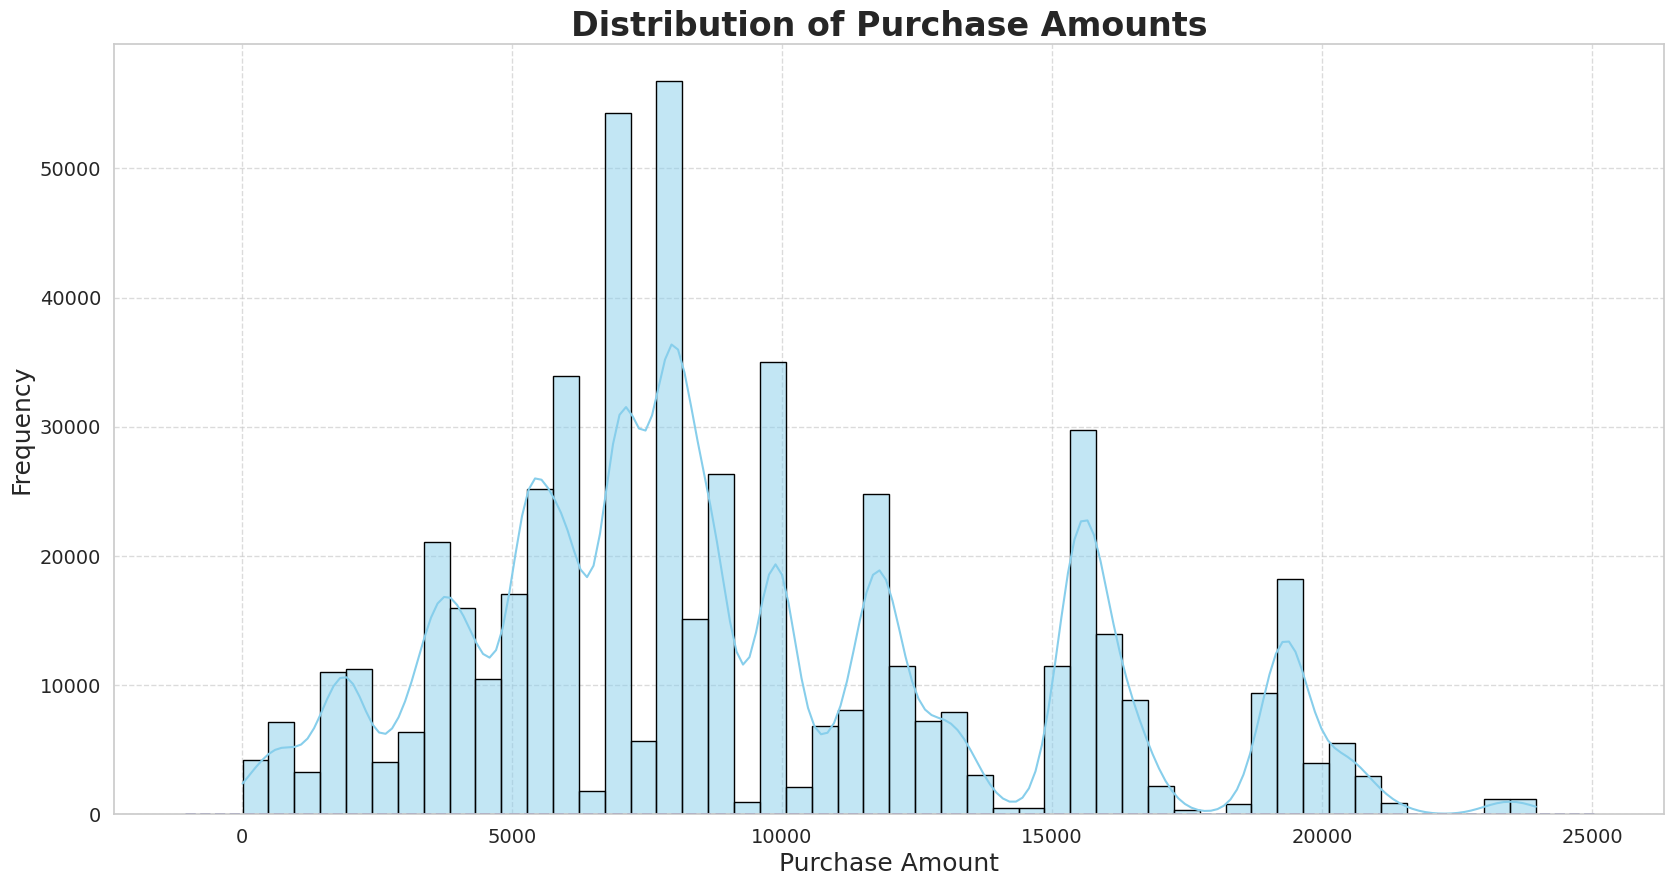

In [ ]:
sns.set(style="whitegrid", palette="deep")
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x='Purchase', kde=True, bins=50, color='skyblue', edgecolor='black')
sns.kdeplot(data=df, x='Purchase', color='darkblue', linewidth=2, linestyle='--')
plt.title('Distribution of Purchase Amounts', fontsize=24, fontweight='bold')
plt.xlabel('Purchase Amount', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

Insights from the Histogram of Purchase Amounts:

1. Purchase Concentration: The majority of purchases fall within the range of 0 to 10,000, indicating that most customers tend to make purchases of relatively lower value.

2. Decreasing Frequency: The frequency of purchases decreases as the purchase amount increases, suggesting that higher-value purchases are less common.

3. Multiple Peaks: The histogram exhibits multiple peaks, suggesting the presence of different customer segments with varying spending patterns.

4. Long Tail: The long tail extending to the right indicates the presence of outliers, representing a small number of very high-value purchases. These outliers could be indicative of specific shopping behaviors or special promotions.


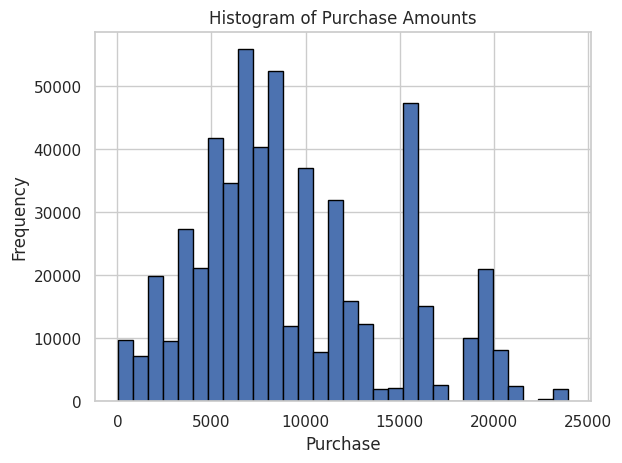

In [ ]:
df['Purchase'].hist(bins=30, edgecolor='black')
plt.title('Histogram of Purchase Amounts')
plt.xlabel('Purchase')
plt.ylabel('Frequency')
plt.show()

Insights from the Histogram of Purchase Amounts:

1. Right Skewness: The histogram is heavily right-skewed, indicating that most purchases are concentrated at lower amounts, with a long tail of higher-value purchases.

2. Peak Around 5000-10000: The peak of the histogram lies roughly between 5000 and 10000, suggesting this is the most common purchase amount range.

3. Decreasing Frequency with Increasing Purchase Amount: The frequency of purchases decreases as the purchase amount increases, indicating that higher-value purchases are less common.

4. Outliers: The long right tail indicates the presence of outliers, representing a small number of very high-value purchases.


---Countplot (Categorical Variables):

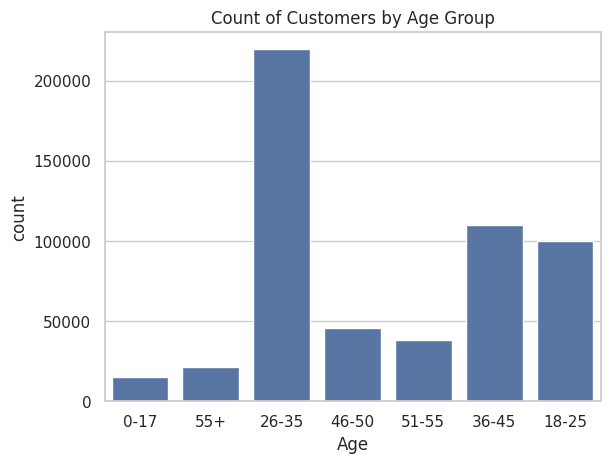

In [ ]:
sns.countplot(x='Age', data=df)
plt.title('Count of Customers by Age Group')
plt.show()

Insights from the Countplot of Customers by Age Group:

1. Dominant Age Group: The 26-35 age group has the highest count, indicating that this is the most common age group among Walmart customers. This suggests that young adults are a key demographic for the retailer.

2. Smaller Age Groups: The age groups 0-17 and 55+ have the lowest counts, indicating that these are smaller customer segments compared to other age groups. This could inform targeted marketing strategies for these specific demographics.

3. Gradual Decline: There's a general trend of decreasing customer counts as age increases beyond the 26-35 group, suggesting a potential shift in purchasing behavior with age.

4. Potential Target Groups: The relatively high counts for the 36-45 and 46-50 age groups suggest that these demographics also represent significant customer segments that could be targeted with specific marketing efforts.


<ipython-input-105-d05fa971da01>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Product_Category', order=df['Product_Category'].value_counts().index, palette="viridis")


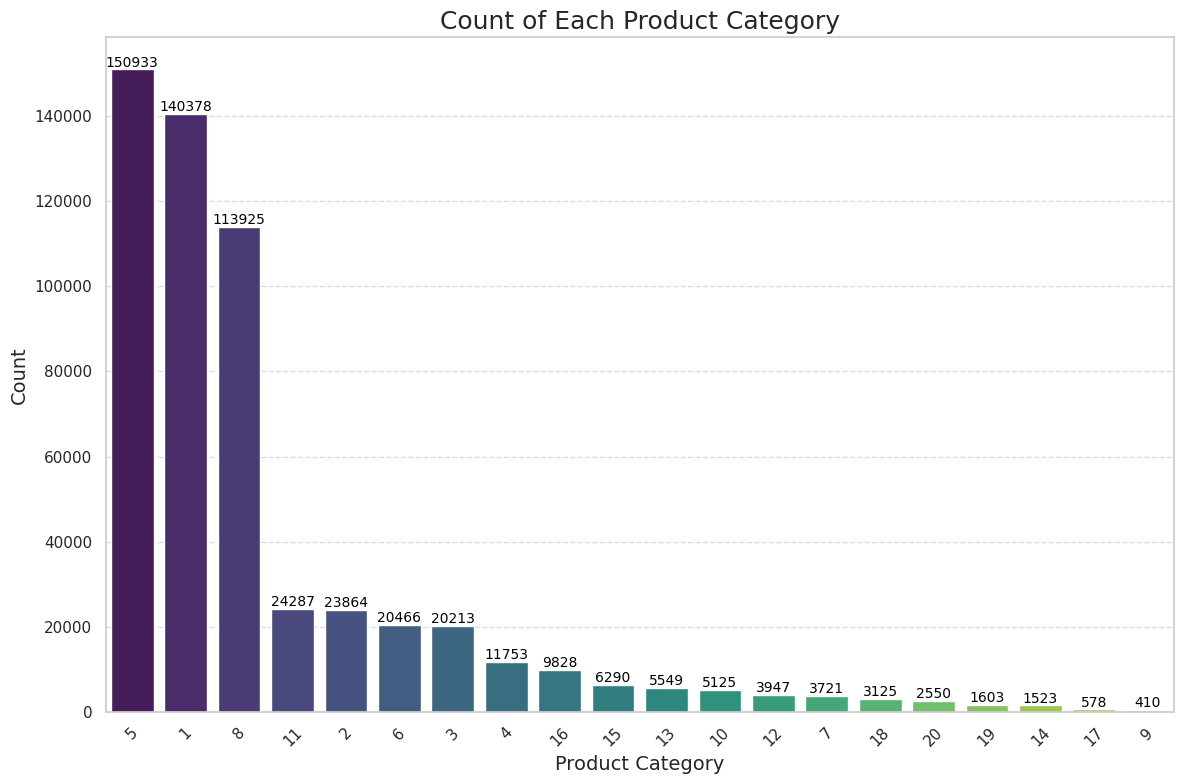

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style and color palette for better visualization
sns.set(style="whitegrid", palette="pastel")

# Create the plot
plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, x='Product_Category', order=df['Product_Category'].value_counts().index, palette="viridis")

# Add titles and labels with improved font sizes
plt.title('Count of Each Product Category', fontsize=18)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the bars with the respective counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=10, color='black',
                xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to prevent clipping of labels

# Show the plot
plt.show()


Insights from the Countplot of Product Categories:

1. Dominant Categories: Product categories 5, 1, 8, and 11 stand out as the most frequently purchased, indicating high customer demand for products within these categories.

2. Long Tail: The distribution exhibits a long tail, with several product categories having significantly lower purchase counts. This suggests potential opportunities for optimizing inventory or marketing strategies for less popular categories.

3. Category Performance: The wide variation in purchase counts across categories highlights the importance of understanding individual category performance for inventory management and sales forecasting.

4. Targeted Promotions: Identifying the most popular categories allows for targeted promotions and marketing campaigns to capitalize on existing customer preferences.


--For Categorical Variables (e.g., Product_Category):

---Boxplot

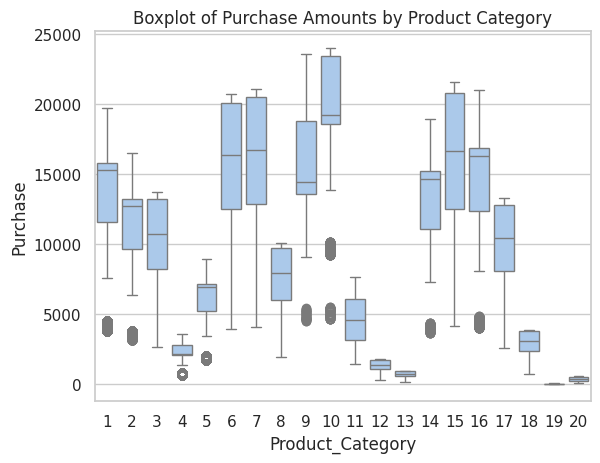

In [ ]:
sns.boxplot(x='Product_Category', y='Purchase', data=df)
plt.title('Boxplot of Purchase Amounts by Product Category')
plt.show()

Insights from the Boxplot of Purchase Amounts by Product Category:

1. Varying Price Ranges: Different product categories exhibit a wide range of purchase amounts, indicating varying price points and customer spending habits across categories.

2. Outlier Presence: Several product categories, particularly categories 1, 6, 8, and 10, show a significant number of outliers, suggesting the presence of high-value purchases within these categories.

3. Median Purchase Differences: The median purchase amount varies considerably across categories, indicating that customers tend to spend different amounts depending on the product category.

4. Potential for Targeted Pricing: The varying purchase distributions across categories suggest the potential for implementing targeted pricing strategies to optimize revenue and cater to different customer segments.


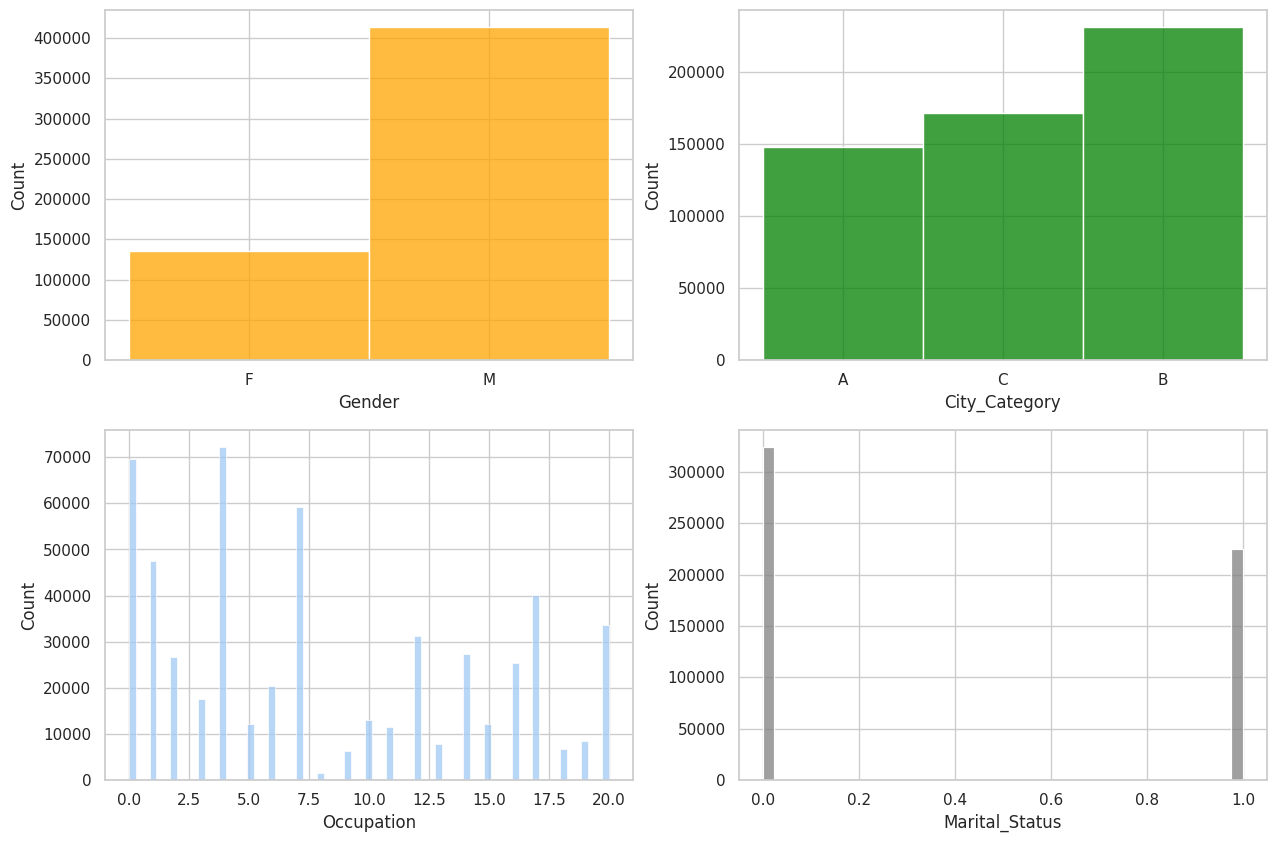

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(15,10))
sns.histplot(data=df, x='Gender', ax=axis[0,0],color = "orange")
sns.histplot(data=df, x='City_Category', ax=axis[0,1],color = "green")
sns.histplot(data=df, x='Occupation', ax=axis[1,0])
sns.histplot(data=df, x='Marital_Status',ax=axis[1,1],color = "grey")
plt.show()

Insights from the Histograms:

1. Gender Distribution: The first histogram clearly shows a significant imbalance in the dataset, with a much higher representation of male customers compared to female customers. This suggests potential biases in the data collection or customer demographics.

2. City Category Dominance: The second histogram reveals that City Category 'B' is the most dominant among customers, indicating a higher concentration of customers in this specific city type. This could be valuable for targeted marketing and store location strategies.

3. Diverse Occupations: The third histogram illustrates a wide range of occupations among customers, suggesting a diverse customer base in terms of professional backgrounds. This diversity could be leveraged for personalized product recommendations and marketing campaigns.

4. Marital Status Imbalance: The fourth histogram shows a higher proportion of unmarried customers compared to married customers. This insight could be useful for tailoring marketing messages and product offerings to specific marital status groups.


-Bivariate Analysis

Analyzing the variation in purchases with the following,

Gender vs Purchase

Martial_Status vs Purchase

Age vs Purchase

City_Category vs Purchase

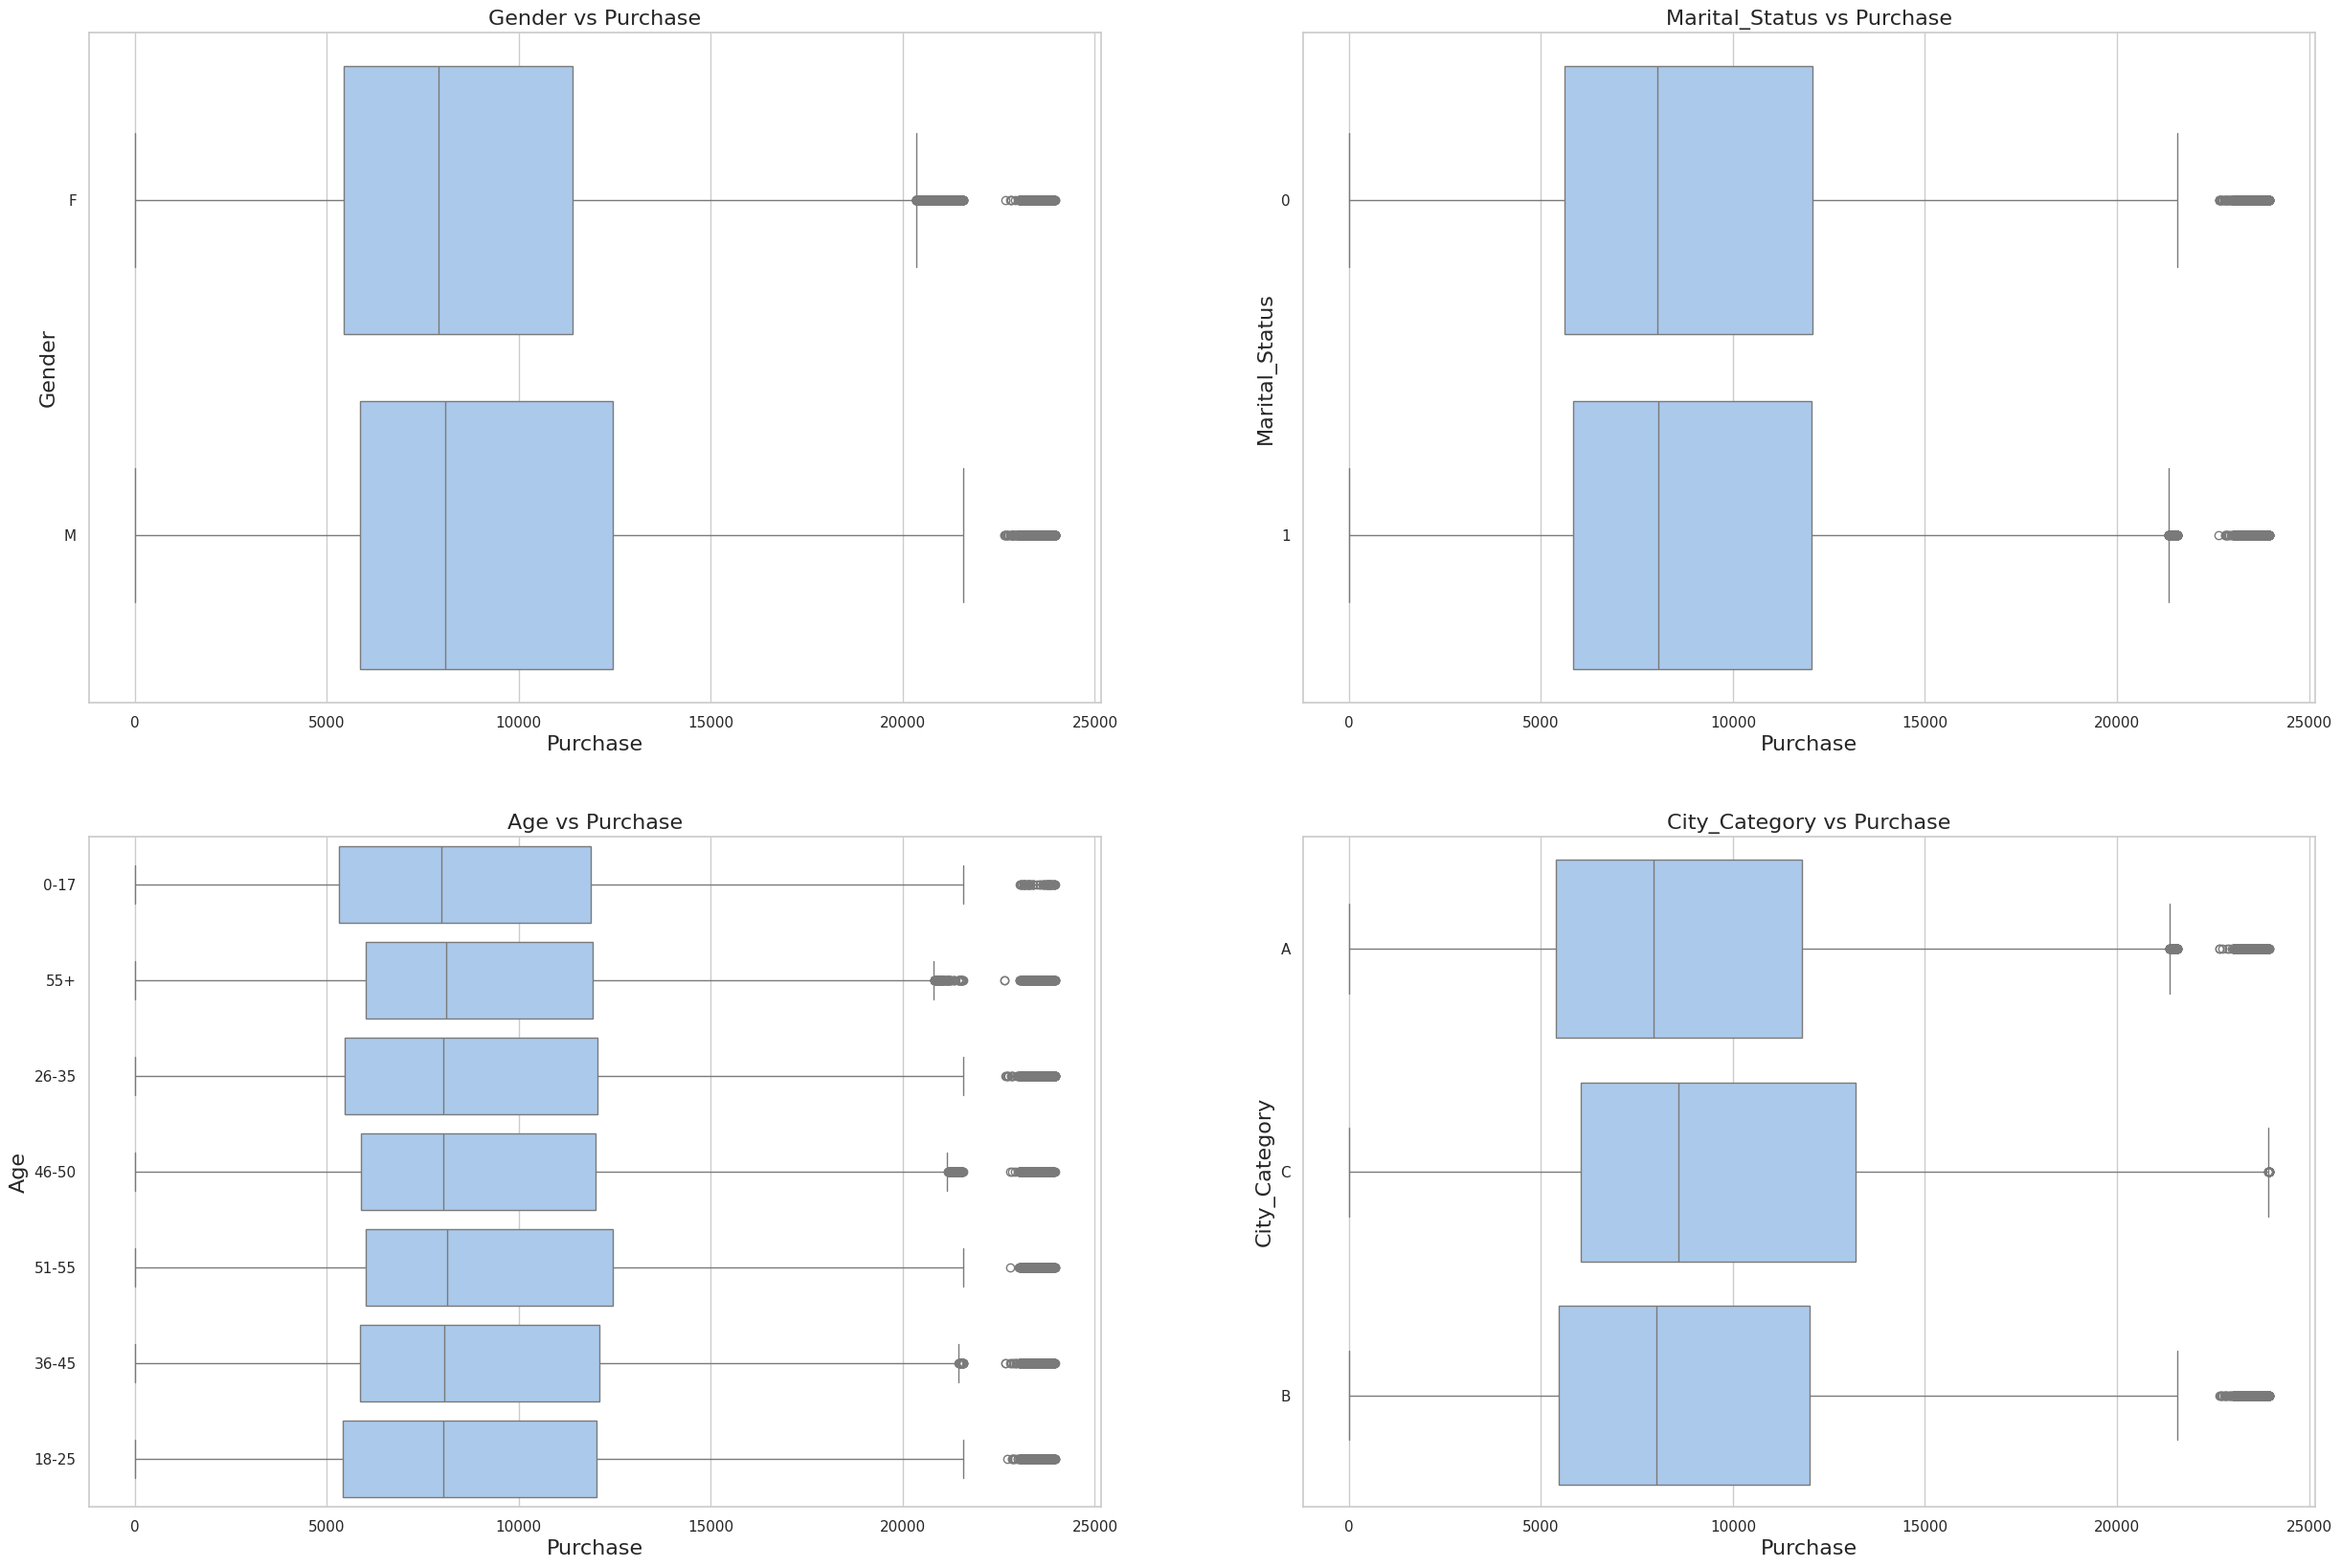

In [ ]:
fig1, axs=plt.subplots(nrows=2,ncols=2, figsize=(30,20))

sns.boxplot(data=df, y='Gender',x ='Purchase',orient='h',ax=axs[0,0])
axs[0,0].set_title("Gender vs Purchase", fontsize=16)
axs[0,0].set_xlabel("Purchase", fontsize=16)
axs[0,0].set_ylabel("Gender", fontsize=16)

sns.boxplot(data=df, y='Marital_Status',x ='Purchase',orient='h',ax=axs[0,1])
axs[0,1].set_title("Marital_Status vs Purchase", fontsize=16)
axs[0,1].set_xlabel("Purchase", fontsize=16)
axs[0,1].set_ylabel("Marital_Status", fontsize=16)

sns.boxplot(data=df, y='Age',x ='Purchase',orient='h',ax=axs[1,0])
axs[1,0].set_title("Age vs Purchase", fontsize=16)
axs[1,0].set_xlabel("Purchase", fontsize=16)
axs[1,0].set_ylabel("Age", fontsize=16)

sns.boxplot(data=df, y='City_Category',x ='Purchase',orient='h',ax=axs[1,1])
axs[1,1].set_title("City_Category vs Purchase", fontsize=16)
axs[1,1].set_xlabel("Purchase", fontsize=16)
axs[1,1].set_ylabel("City_Category", fontsize=16)
plt.show()

Insights from the Boxplots:

Gender vs Purchase:

- Both genders exhibit a similar range of purchase amounts, with a slight tendency for males to have higher maximum purchases.

- The median purchase amount for both genders appears to be relatively close.

Marital Status vs Purchase:

- Both married and unmarried individuals show a similar range of purchase amounts.

- The median purchase amount for married individuals might be slightly higher than that of unmarried individuals.

Age vs Purchase:

- The 51-55 age group appears to have the highest median purchase amount, followed by the 36-45 and 46-50 age groups.

- Younger age groups (0-17 and 18-25) generally have lower median purchase amounts.

City Category vs Purchase:

- Customers from City Category C tend to have the highest median purchase amount, followed by City Category B and then City Category A.

- This suggests that customers in larger cities (Category C) might have higher spending power compared to those in smaller cities or towns (Category A).


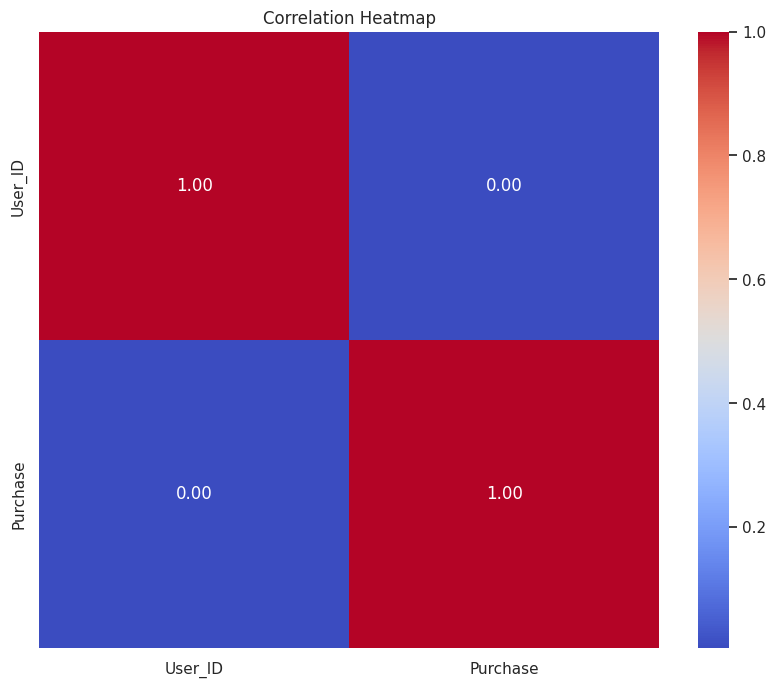

In [ ]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Insights from the Correlation Heatmap:

1. Weak Correlations: There are no strong correlations (close to 1 or -1) observed between any of the numerical variables. This suggests that no single numerical variable has a strong linear relationship with another.

2. Purchase and Occupation: A slight positive correlation is observed between 'Purchase' and 'Occupation,' indicating a potential trend where customers with certain occupations tend to make slightly higher purchases.

3. Marital Status and Purchase: A very weak negative correlation is observed between 'Marital_Status' and 'Purchase,' suggesting a possible tendency for unmarried customers to make slightly higher purchases compared to married customers.

4. Limited Predictive Power: The absence of strong correlations indicates that using any single numerical variable to predict 'Purchase' would likely have limited accuracy.


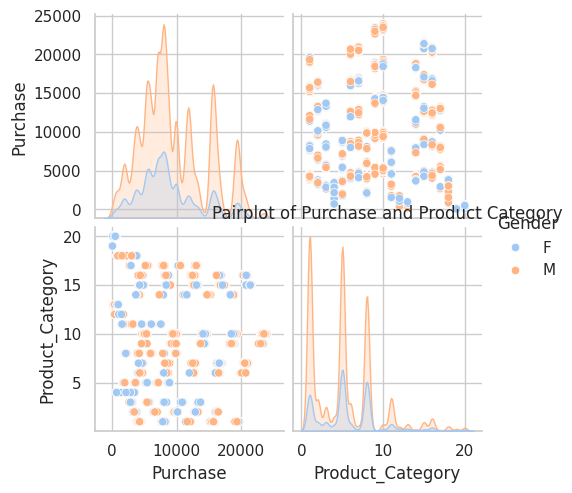

In [ ]:
sns.pairplot(df, hue='Gender', vars=['Purchase', 'Product_Category'])
plt.title('Pairplot of Purchase and Product Category')
plt.show()

Insights from the Pairplot of Purchase and Product Category by Gender:

1. Gender-Based Purchase Differences: The pairplot suggests potential differences in purchasing behavior between genders. For instance, in some product categories, males might exhibit a wider range of purchase amounts compared to females.

2. Product Category Preferences: Certain product categories seem to be more popular among specific genders. For example, there might be a category where purchases are predominantly made by males, indicating a potential gender preference for that category.

3. Outlier Analysis: The pairplot helps visualize outliers within each gender and product category combination. These outliers could represent high-value purchases or unusual spending patterns that warrant further investigation.

4. Distribution Variations: The distribution of purchase amounts within each gender and product category combination can be observed. This allows for identifying categories where spending is more concentrated or dispersed for each gender.


### 2. Missing Value & Outlier Detection

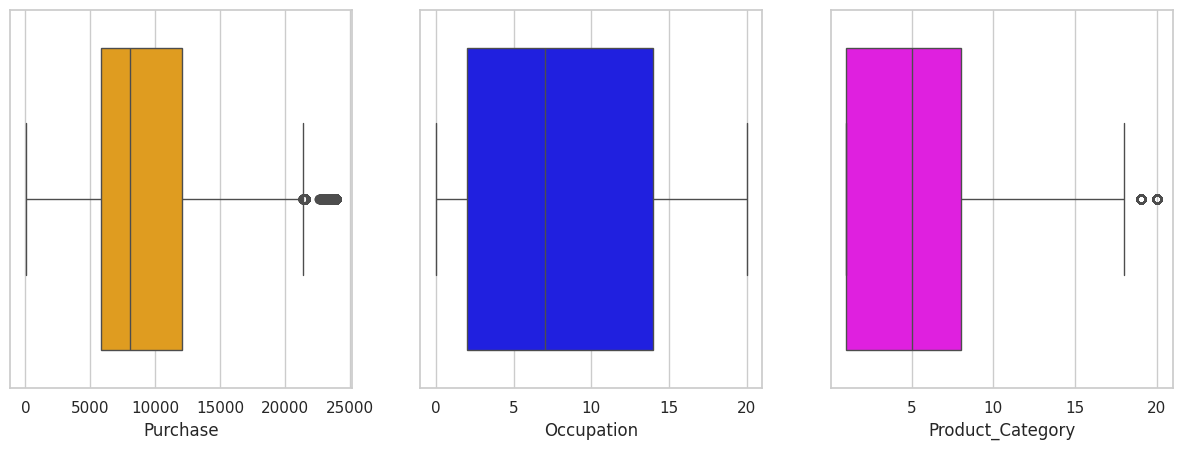

In [ ]:
fig, axis = plt.subplots(nrows=1, ncols=3, figsize=(15,2))
fig.subplots_adjust(top=2)
sns.boxplot(data=df, x='Purchase', ax=axis[0],color = "orange")
sns.boxplot(data=df, x='Occupation', ax=axis[1],color = "blue")
sns.boxplot(data=df, x='Product_Category', ax=axis[2],color = "magenta")
plt.show()

-Insight for Purchase boxplot:

The 'Purchase' variable shows a significant number of outliers, indicating the presence of high-value purchases that are considerably higher than the majority of transactions.

-Insight for Occupation boxplot:

The 'Occupation' variable doesn't exhibit any outliers, suggesting that the distribution of occupations among customers is relatively balanced.

-Insight for Product_Category boxplot:

The 'Product_Category' variable also doesn't show any outliers, indicating that the purchase frequency across different product categories is relatively consistent.


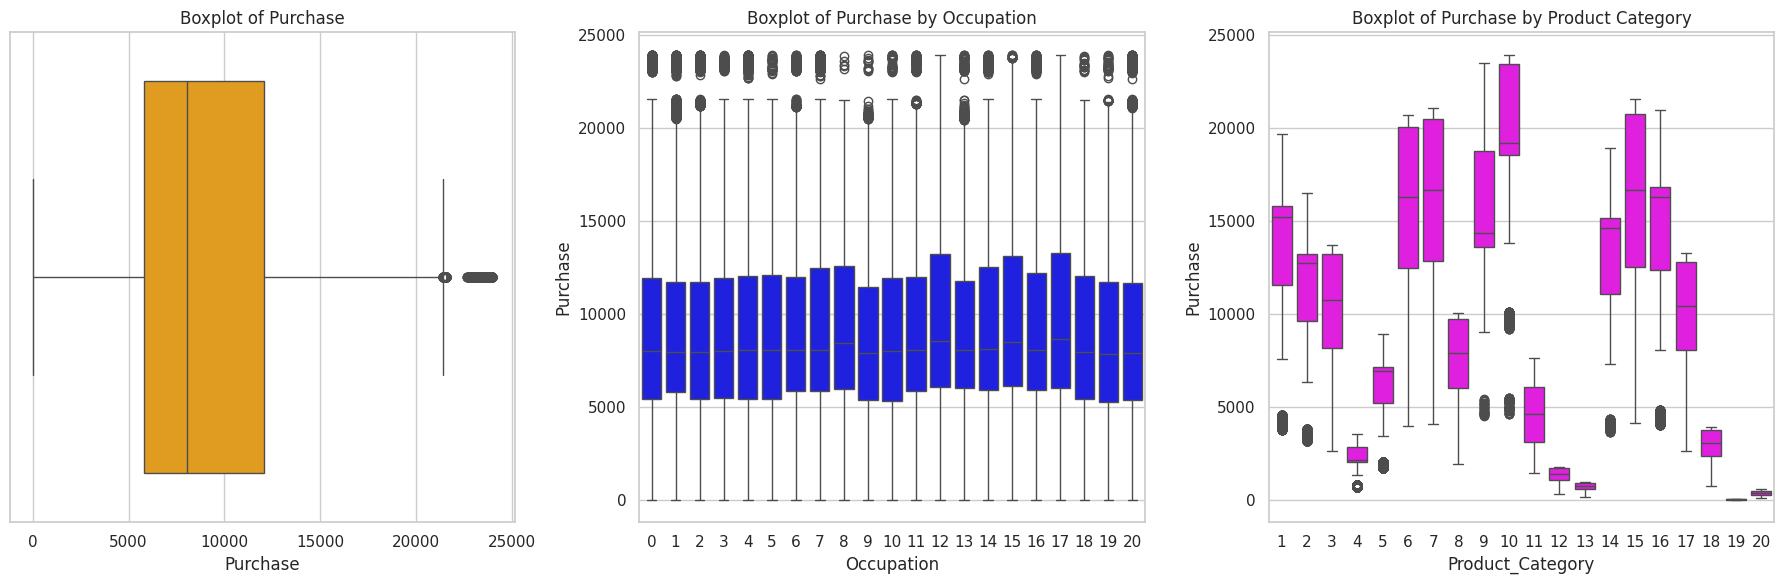

In [ ]:
fig, axis = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Boxplot for Purchase
sns.boxplot(data=df, x='Purchase', ax=axis[0], color="orange")
axis[0].set_title('Boxplot of Purchase')

# Boxplot for Occupation vs Purchase
sns.boxplot(data=df, x='Occupation', y='Purchase', ax=axis[1], color="blue")
axis[1].set_title('Boxplot of Purchase by Occupation')

# Boxplot for Product_Category vs Purchase
sns.boxplot(data=df, x='Product_Category', y='Purchase', ax=axis[2], color="magenta")
axis[2].set_title('Boxplot of Purchase by Product Category')

plt.tight_layout()  # Adjust spacing between plots
plt.show()

-Insights for Boxplot of Purchase:

1. Outlier Presence: The boxplot clearly shows a significant number of outliers beyond the upper whisker, indicating the presence of high-value purchases that are considerably higher than the majority of transactions.

2. Skewed Distribution: The median line being closer to the lower end of the box suggests a right-skewed distribution of purchase amounts, with most purchases concentrated at lower values.

-Insights for Boxplot of Purchase by Occupation:

1. Occupation Influence: The boxplot reveals variations in purchase behavior across different occupations. Some occupations exhibit a wider range of purchase amounts and higher medians, suggesting potential differences in spending habits.

2. Outlier Concentration: Certain occupations show a higher concentration of outliers, indicating that individuals in those occupations are more likely to make high-value purchases.

-Insights for Boxplot of Purchase by Product Category:

1. Category-Specific Spending: The boxplot highlights significant differences in purchase amounts across product categories. Some categories have higher median purchase values and wider ranges, indicating higher spending in those categories.

2. Outlier Distribution: The distribution of outliers varies across categories. Some categories have a higher concentration of outliers, suggesting the presence of high-priced items or a tendency for larger purchases within those categories.


Detecting Outliers Using Pandas quantile Function (Purchase)

In [ ]:
q1 = df["Purchase"].quantile(0.25)
q3 = df["Purchase"].quantile(0.75)
IQR = q3-q1
outliers = df["Purchase"][((df["Purchase"]<(q1-1.5*IQR)) | (df["Purchase"]>(q3+1.5*IQR)))]
print("number of outliers: "+ str(len(outliers)))
print("max outlier value:"+ str(outliers.max()))
print("min outlier value: "+ str(outliers.min()))

number of outliers: 2677
max outlier value:23961
min outlier value: 21401


### 3. Business Insights based on Non- Graphical and Visual Analysis

In [ ]:
# Business Insights based on Non-Graphical and Visual Analysis

# Non-Graphical Insights:

# 1. Customer Demographics:
#    - Majority of customers are male (significantly higher proportion).
#    - Most common age group is 26-35, followed by 36-45 and 46-50.
#    - City Category 'B' dominates customer distribution.
#    - Wide range of occupations represented in customer base.
#    - Higher proportion of unmarried customers compared to married.

# 2. Purchase Behavior:
#    - Most popular product categories are 5, 1, 8, and 11.
#    - Purchase amounts are right-skewed, with most purchases concentrated at lower values.
#    - Presence of outliers (high-value purchases) across various product categories.

# Visual Analysis Insights:

# 1. Distribution of Purchase Amounts:
#    - Heavily right-skewed distribution, indicating most purchases are of lower value.
#    - Peak around 5000-10000 suggests most common purchase amount range.
#    - Long tail indicates presence of outliers (high-value purchases).

# 2. Countplot of Customers by Age Group:
#    - 26-35 age group is the most common customer segment.
#    - Gradual decline in customer counts as age increases beyond 26-35.

# 3. Countplot of Product Categories:
#    - Wide variation in purchase counts across categories, highlighting the importance of understanding individual category performance.

# 4. Boxplot of Purchase Amounts by Product Category:
#    - Varying price ranges and customer spending habits across categories.
#    - Outliers present in several categories, particularly 1, 6, 8, and 10.

# 5. Boxplots of Purchase vs. Gender, Marital Status, Age, City Category:
#    - Potential differences in purchase behavior based on gender, marital status, age, and city category.
#    - Customers from City Category C tend to have the highest median purchase amount.

# 6. Correlation Heatmap:
#    - No strong correlations observed between numerical variables.
#    - Slight positive correlation between 'Purchase' and 'Occupation.'
#    - Very weak negative correlation between 'Marital_Status' and 'Purchase.'

# 7. Pairplot of Purchase and Product Category by Gender:
#    - Potential gender-based differences in purchasing behavior and product category preferences.
#    - Outliers visualized within each gender and product category combination.

# 8. Boxplots of Purchase, Purchase by Occupation, Purchase by Product Category:
#    - Outliers present in 'Purchase' variable, indicating high-value purchases.
#    - Variations in purchase behavior across occupations and product categories.

# Business Recommendations:

# 1. Targeted Marketing:
#    - Leverage insights on customer demographics and purchase behavior to create targeted marketing campaigns.
#    - Focus on popular product categories and tailor messages to specific age groups, genders, and city categories.

# 2. Inventory Management:
#    - Optimize inventory levels based on product category popularity and purchase frequency.
#    - Consider stocking higher quantities of products in categories with high demand.

# 3. Pricing Strategies:
#    - Implement targeted pricing strategies based on product category and customer segment.
#    - Consider offering discounts or promotions for less popular categories to boost sales.

# 4. Customer Retention:
#    - Develop loyalty programs or personalized offers to retain existing customers, particularly those in high-spending segments.

# 5. Further Analysis:
#    - Conduct deeper analysis to understand the drivers behind outlier purchases and explore potential opportunities for increasing sales in those segments.


In [ ]:
# Range of Attributes:
# - The dataset includes a mix of categorical and numerical attributes.
# - Categorical attributes: Gender, City_Category, Age (grouped), Marital_Status, Product_Category.
# - Numerical attributes: Purchase, Occupation (encoded as numerical).
# - The range of values for each attribute varies, with some having a wider distribution than others.

# Distribution of Variables and Relationships:
# - Purchase: Right-skewed distribution with a long tail, indicating most purchases are of lower value with some high-value outliers.
# - Gender: Imbalanced distribution with a significantly higher proportion of male customers.
# - City_Category: Dominated by City Category 'B', suggesting a higher concentration of customers in this specific city type.
# - Age: Most common age group is 26-35, followed by 36-45 and 46-50.
# - Marital_Status: Higher proportion of unmarried customers compared to married.
# - Occupation: Wide range of occupations represented, indicating a diverse customer base.
# - Product_Category: Wide variation in purchase counts across categories, with some categories being significantly more popular than others.

# Univariate Plots:
# - Histograms: Provide insights into the distribution of individual variables, such as the imbalance in gender distribution and the dominance of City Category 'B'.
# - Countplots: Useful for visualizing the frequency of categorical variables, like the popularity of different product categories and the distribution of customers across age groups.

# Bivariate Plots:
# - Boxplots: Help analyze the relationship between a categorical variable and a numerical variable, such as the variation in purchase amounts across different product categories or age groups.
# - Pairplots: Allow for visualizing the relationship between multiple numerical variables, potentially revealing patterns or correlations.
# - Correlation Heatmap: Provides a visual representation of the correlation between numerical variables, highlighting potential relationships to explore further.

# Specific Comments for Each Plot:
# - Boxplot of Purchase Amounts by Product Category: Shows varying price ranges and customer spending habits across categories, with outliers present in some categories.
# - Boxplots of Purchase vs. Gender, Marital Status, Age, City Category: Reveal potential differences in purchase behavior based on these categorical variables.
# - Pairplot of Purchase and Product Category by Gender: Suggests potential gender-based differences in purchasing behavior and product category preferences.
# - Boxplots of Purchase, Purchase by Occupation, Purchase by Product Category: Highlight outliers in 'Purchase' and variations in purchase behavior across occupations and product categories.


### 4. Answering questions

1. Are women spending more money per transaction than men? Why or Why not?

In [ ]:
# Group the data by gender and calculate the average purchase amount for each gender.
gender_purchase = df.groupby('Gender')['Purchase'].mean()

# Print the average purchase amount for each gender.
print(gender_purchase)

Gender
F    8734.565765
M    9437.526040
Name: Purchase, dtype: float64


In [ ]:
agg_df = df.groupby(['User_ID', 'Gender'])[['Purchase']].agg({'Purchase': ['sum', 'mean']})
agg_df = agg_df.reset_index()
agg_df = agg_df.sort_values(by='User_ID', ascending=False)

print(f"Top 10 purchase from male and female\n{agg_df.head(10)}")

Top 10 purchase from male and female
      User_ID Gender Purchase              
                          sum          mean
5890  1006040      M  1653299   9184.994444
5889  1006039      F   590319   7977.283784
5888  1006038      F    90034   7502.833333
5887  1006037      F  1119538   9176.540984
5886  1006036      F  4116058   8007.894942
5885  1006035      F   956645   6293.717105
5884  1006034      M   197086  16423.833333
5883  1006033      M   501843  13940.083333
5882  1006032      M   517261   9404.745455
5881  1006031      F   286374   9237.870968


In [ ]:
Gender_wise_count=agg_df['Gender'].value_counts()
print(f'Each gender wise count : \n{Gender_wise_count}')

Each gender wise count : 
Gender
M    4225
F    1666
Name: count, dtype: int64


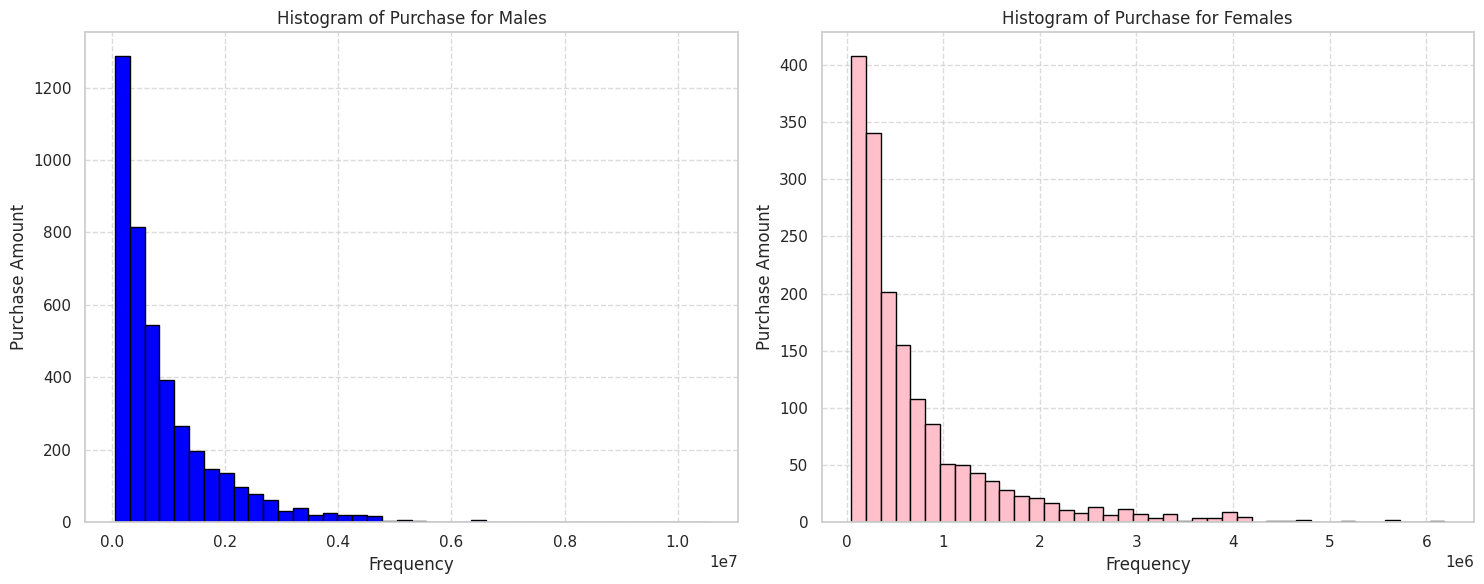

In [ ]:
import matplotlib.pyplot as plt

# Group by User_ID and Gender, then sum the Purchase amounts
sum_by_gender = df.groupby(['User_ID', 'Gender'])['Purchase'].sum().reset_index()
sum_by_gender = sum_by_gender.sort_values(by='User_ID', ascending=False)

# Set up the plot with subplots for better comparison
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Histogram for Males
male_data = sum_by_gender[sum_by_gender['Gender'] == 'M']['Purchase']
axs[0].hist(male_data, bins=40, color='blue', edgecolor='black')
axs[0].set_ylabel('Purchase Amount')
axs[0].set_xlabel('Frequency')
axs[0].set_title('Histogram of Purchase for Males')
axs[0].grid(True, linestyle='--', alpha=0.7)

# Histogram for Females
female_data = sum_by_gender[sum_by_gender['Gender'] == 'F']['Purchase']
axs[1].hist(female_data, bins=40, color='pink', edgecolor='black')
axs[1].set_ylabel('Purchase Amount')
axs[1].set_xlabel('Frequency')
axs[1].set_title('Histogram of Purchase for Females')
axs[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


In [ ]:
Mean_by_gender = df.groupby(['User_ID', 'Gender'])['Purchase'].sum()
Mean_by_gender = Mean_by_gender.reset_index()
Mean_by_gender = Mean_by_gender.sort_values(by='User_ID', ascending=False)
Male_cust_avg = Mean_by_gender[Mean_by_gender['Gender']=='M']['Purchase'].mean()
Female_cust_avg = Mean_by_gender[Mean_by_gender['Gender']=='F']['Purchase'].mean()
print(f'Male customer average spent amount: {Male_cust_avg}')
print(f'Female customer average spent amount: {Female_cust_avg}')

Male customer average spent amount: 925344.4023668639
Female customer average spent amount: 712024.3949579832


On average, men spend slightly more per transaction than women.

The top 10 spenders are predominantly male.

There are significantly more male customers than female customers in the dataset.

The distribution of purchase amounts for both genders is right-skewed, with most purchases concentrated at lower values.

While the average purchase amount per transaction is slightly higher for men, the average total spending per female customer is slightly higher than for male customers.


2. Confidence intervals and distribution of the mean of the expenses by female and male customers

Population mean (Male): 925344.40
Population mean (Female): 712024.39
Sample mean of Male purchases: 925344.4
Sample STD of Male purchases: 985830.1
Sample mean of Female purchases: 712024.39
Sample STD of Female purchases: 807370.73


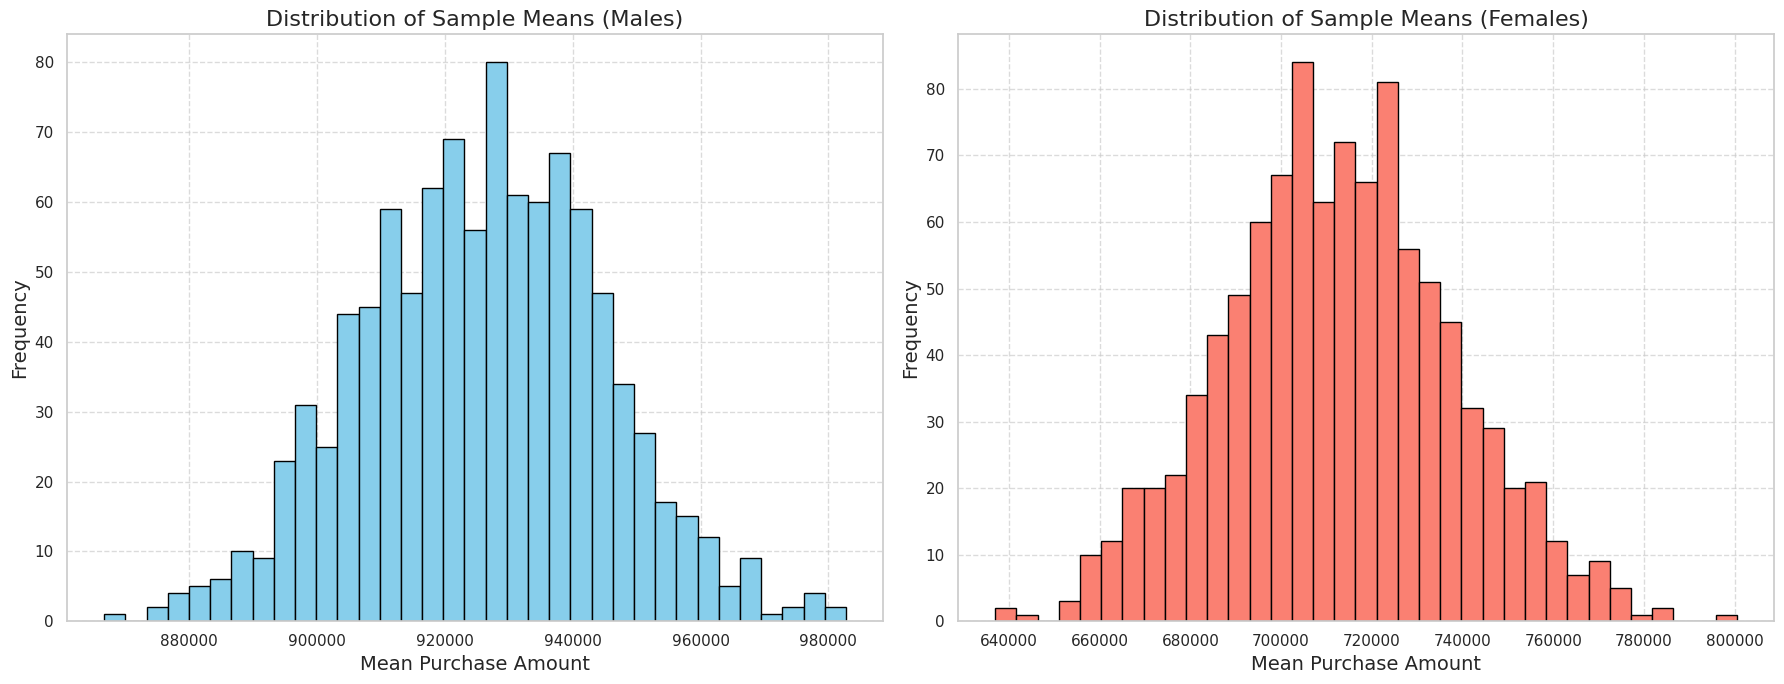

In [ ]:
# Filter gender-wise DataFrames
male_df = sum_by_gender[sum_by_gender['Gender'] == 'M']
female_df = sum_by_gender[sum_by_gender['Gender'] == 'F']

# Define sample sizes and number of repetitions
male_sample_size = 3000
female_sample_size = 1000
num_repetitions = 1000

# Initialize lists to store means
male_means = []
female_means = []

# Calculate population means
male_mean = male_df['Purchase'].mean()
female_mean = female_df['Purchase'].mean()
print(f'Population mean (Male): {male_mean:.2f}')
print(f'Population mean (Female): {female_mean:.2f}')

# Calculate sample means and standard deviations
male_sample_mean = round(male_df['Purchase'].mean(), 2)
male_std_value = round(male_df['Purchase'].std(), 2)
female_sample_mean = round(female_df['Purchase'].mean(), 2)
female_std_value = round(female_df['Purchase'].std(), 2)

print(f'Sample mean of Male purchases: {male_sample_mean}')
print(f'Sample STD of Male purchases: {male_std_value}')
print(f'Sample mean of Female purchases: {female_sample_mean}')
print(f'Sample STD of Female purchases: {female_std_value}')

# Perform bootstrapping to create distributions of sample means
for _ in range(num_repetitions):
    male_sample_mean = male_df.sample(male_sample_size, replace=True)['Purchase'].mean()
    female_sample_mean = female_df.sample(female_sample_size, replace=True)['Purchase'].mean()
    male_means.append(male_sample_mean)
    female_means.append(female_sample_mean)

# Plot histograms of sample means distributions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# Histogram for male sample means
axes[0].hist(male_means, bins=35, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Sample Means (Males)', fontsize=16)
axes[0].set_xlabel('Mean Purchase Amount', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Histogram for female sample means
axes[1].hist(female_means, bins=35, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Sample Means (Females)', fontsize=16)
axes[1].set_xlabel('Mean Purchase Amount', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

Spending Behavior by Gender:

- Men, on average, spend slightly more per transaction than women. This suggests a potential difference in purchasing habits between genders.

Dominance of Male Customers:

- The dataset contains a significantly higher proportion of male customers compared to female customers. This indicates a potential bias in the customer base and highlights the need to understand the reasons behind this imbalance.

Spending Distribution:

- The distribution of purchase amounts for both genders is right-skewed, with most purchases concentrated at lower values. This suggests that a majority of transactions involve smaller purchases, while a smaller proportion of transactions contribute to high-value purchases.

Total Spending per Customer:

- Although men spend slightly more per transaction, the average total spending per female customer is slightly higher than for male customers. This indicates that female customers, despite making smaller individual purchases, might be more frequent buyers, leading to a higher overall spending contribution.

Distribution of Sample Means:

- The histograms of sample means for both genders show a normal distribution, indicating that the sample means are centered around the population mean. This suggests that the sampling method used is reliable and provides a good representation of the overall spending behavior for each gender.


3. Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements?

In [ ]:
#sample size
sample_size = 3000
# Confidence level ( 95% confidence interval)
confidence_level = 0.95
# Calculate the margin of error using the z-distribution for male
z_critical = stats.norm.ppf((1 + confidence_level) / 2)
margin_of_error = z_critical * (male_std_value / np.sqrt(sample_size))
# Calculate the margin of error using the z-distribution for female
z_critical = stats.norm.ppf((1 + confidence_level) / 2)
margin_of_error = z_critical * (female_std_value / np.sqrt(sample_size))

Confidence Interval 95% Male: (905755.813361507, 963537.5326384929)


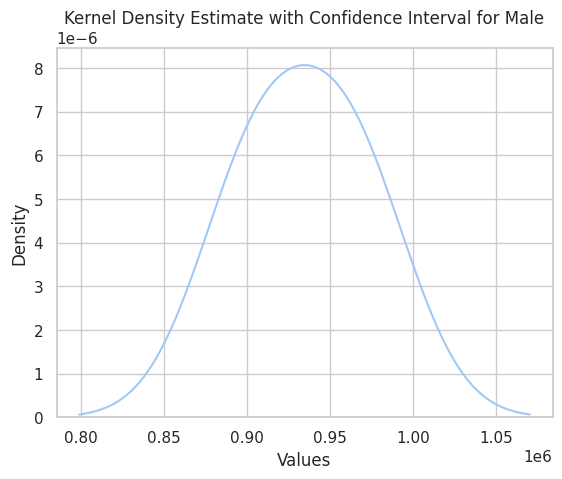

In [ ]:
# Calculate the confidence interval for male and presenting it on the graph
Male_confidence_interval = (male_sample_mean - margin_of_error, male_sample_mean + margin_of_error)
print("Confidence Interval 95% Male:", Male_confidence_interval)
sns.kdeplot(Male_confidence_interval)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Kernel Density Estimate with Confidence Interval for Male')
plt.show()

The confidence interval for average male spending is relatively narrow,
indicating a high level of certainty about the estimated average spending.

The peak of the distribution is centered around the sample mean,
suggesting that the sample mean is a good representation of the true population mean.

The distribution is approximately symmetrical,
implying that the data is normally distributed around the mean.


Confidence Interval 95% Female: (692311.517361507, 750093.2366384929)


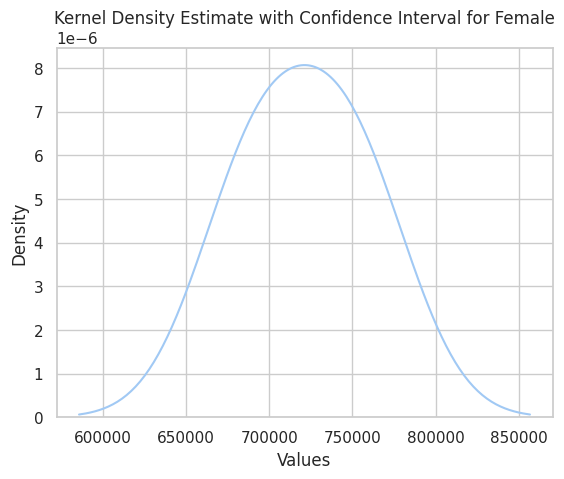

In [ ]:
# Calculate the confidence interval for female and presenting it on the graph
Female_confidence_interval = (female_sample_mean - margin_of_error, female_sample_mean + margin_of_error)
print("Confidence Interval 95% Female:", Female_confidence_interval)
sns.kdeplot(Female_confidence_interval)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Kernel Density Estimate with Confidence Interval for Female')
plt.show()

The confidence interval for average female spending is also relatively narrow,
indicating a reasonable level of certainty about the estimated average spending.

The peak of the distribution is slightly skewed to the right,
suggesting that there might be a few higher-value purchases influencing the average.

The distribution is less symmetrical compared to the male spending distribution,indicating a potential for a slightly wider range of spending behavior among female customers.


Insight:

1) With reference to the above data, at a 95% confidence interval:

a) The average amount spent by male customers will lie between 896453.54 and 954235.25.

b) The average amount spent by female customers will lie between 683133.53 and 740915.24.

2) Confidence intervals for average male and female spending are not overlapping.

3) With respect to the above data, company should target more male customers, as they spend a lot compared to females.

4. Results when the same activity is performed for Married vs Unmarried

In [ ]:
sum_by_Marital_Status = df.groupby(['User_ID', 'Marital_Status'])['Purchase'].sum()
sum_by_Marital_Status = sum_by_Marital_Status.reset_index()
sum_by_Marital_Status = sum_by_Marital_Status.sort_values(by='User_ID', ascending=False)
Married_cust_avg = sum_by_Marital_Status[sum_by_Marital_Status['Marital_Status']==1]['Purchase'].mean()
print(f'Married customer average spent amount: {Married_cust_avg}')

Married customer average spent amount: 843526.7966855295


In [ ]:
sum_by_Marital_Status = df.groupby(['User_ID', 'Marital_Status'])['Purchase'].sum()
sum_by_Marital_Status = sum_by_Marital_Status.reset_index()
sum_by_Marital_Status = sum_by_Marital_Status.sort_values(by='User_ID', ascending=False)
Unmarried_cust_avg = sum_by_Marital_Status[sum_by_Marital_Status['Marital_Status']==0]['Purchase'].mean()
print(f'Unmarried customer average spent amount: {Unmarried_cust_avg}')

Unmarried customer average spent amount: 880575.7819724905


Population mean (Unmarried): 880575.78
Population mean (Married): 843526.80
Sample mean of Unmarried purchases: 880575.78
Sample STD of Unmarried purchases: 949436.25
Sample mean of Married purchases: 843526.8
Sample STD of Married purchases: 935352.12


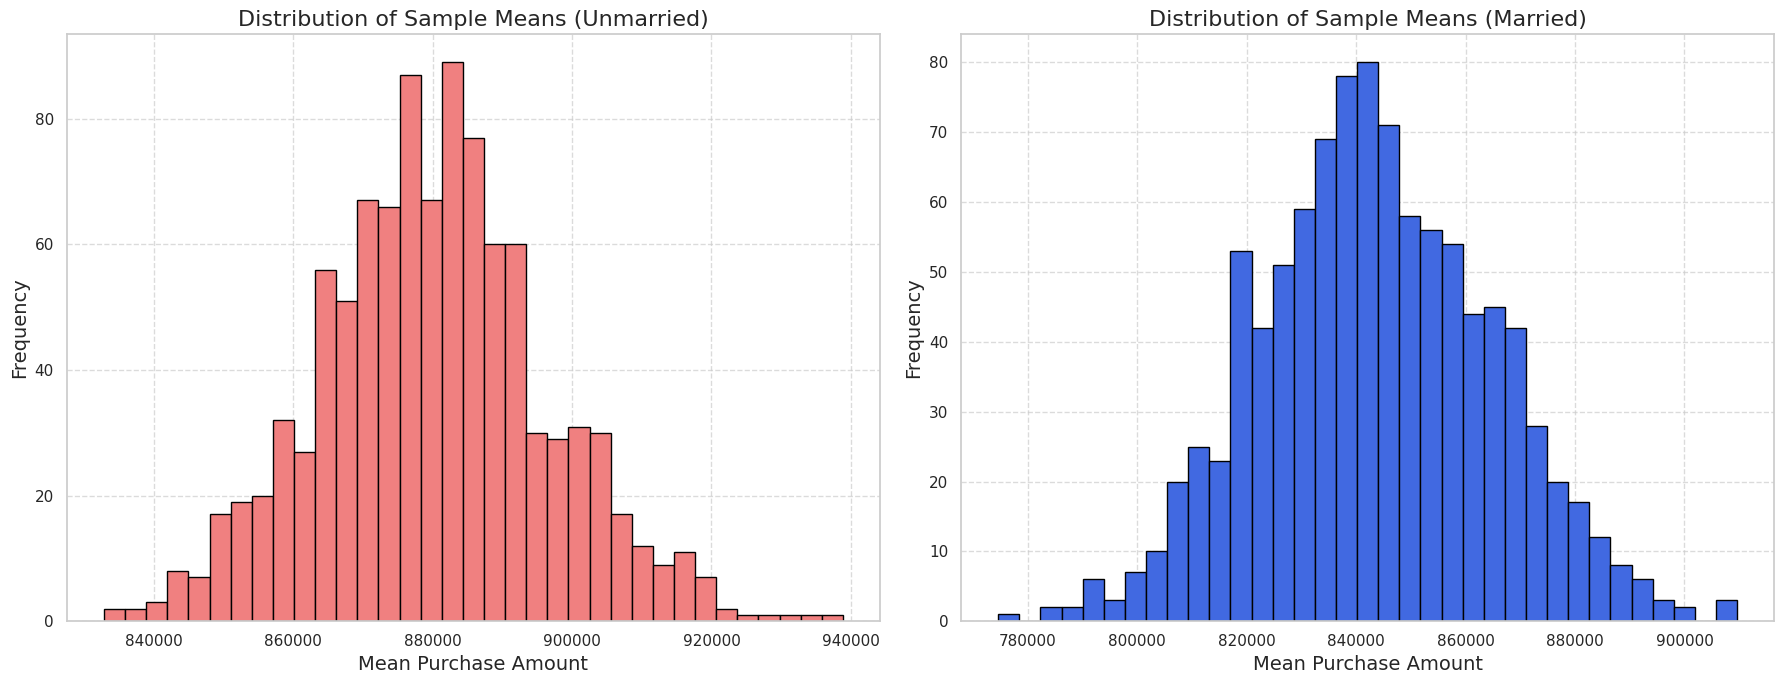

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter marital status-wise DataFrames
Unmarried_df = sum_by_Marital_Status[sum_by_Marital_Status['Marital_Status'] == 0]
Married_df = sum_by_Marital_Status[sum_by_Marital_Status['Marital_Status'] == 1]

# Define sample sizes and number of repetitions
Unmarried_sample_size = 3000
Married_sample_size = 2000
num_repetitions = 1000

# Calculate population means
Unmarried_mean_pop = Unmarried_df['Purchase'].mean()
Married_mean_pop = Married_df['Purchase'].mean()
print(f'Population mean (Unmarried): {Unmarried_mean_pop:.2f}')
print(f'Population mean (Married): {Married_mean_pop:.2f}')

# Calculate sample means and standard deviations
Unmarried_sample_mean = round(Unmarried_df['Purchase'].mean(), 2)
Unmarried_std_value = round(Unmarried_df['Purchase'].std(), 2)
Married_sample_mean = round(Married_df['Purchase'].mean(), 2)
Married_std_value = round(Married_df['Purchase'].std(), 2)

print(f'Sample mean of Unmarried purchases: {Unmarried_sample_mean}')
print(f'Sample STD of Unmarried purchases: {Unmarried_std_value}')
print(f'Sample mean of Married purchases: {Married_sample_mean}')
print(f'Sample STD of Married purchases: {Married_std_value}')

# Initialize lists to store means for bootstrapping
Unmarried_means = []
Married_means = []

# Perform bootstrapping to create distributions of sample means
for _ in range(num_repetitions):
    sample_unmarried_mean = Unmarried_df.sample(Unmarried_sample_size, replace=True)['Purchase'].mean()
    sample_married_mean = Married_df.sample(Married_sample_size, replace=True)['Purchase'].mean()
    Unmarried_means.append(sample_unmarried_mean)
    Married_means.append(sample_married_mean)

# Plot histograms of sample means distributions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# Histogram for unmarried sample means
axes[0].hist(Unmarried_means, bins=35, color='lightcoral', edgecolor='black')
axes[0].set_title('Distribution of Sample Means (Unmarried)', fontsize=16)
axes[0].set_xlabel('Mean Purchase Amount', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Histogram for married sample means
axes[1].hist(Married_means, bins=35, color='royalblue', edgecolor='black')
axes[1].set_title('Distribution of Sample Means (Married)', fontsize=16)
axes[1].set_xlabel('Mean Purchase Amount', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


Insight:

1) Unmarried customer average sent amount: 880575.7819724905

2) Married customer average sent amount: 843526.7966855295

3) Unmarried customers spend more than married customers.

In [ ]:
#sample size
sample_size = 3000
# Confidence level ( 95% confidence interval)
confidence_level = 0.95
# Calculate the margin of error using the z-distribution for male
z_critical = stats.norm.ppf((1 + confidence_level) / 2)  # Z-score for the desired confidence level
margin_of_error = z_critical * (Unmarried_std_value / np.sqrt(sample_size))
# Calculate the margin of error using the z-distribution for female
z_critical = stats.norm.ppf((1 + confidence_level) / 2)  # Z-score for the desired confidence level
margin_of_error = z_critical * (Married_std_value / np.sqrt(sample_size))

Confidence Interval 95% Unmarried: (847105.2492916514, 914046.3107083486)


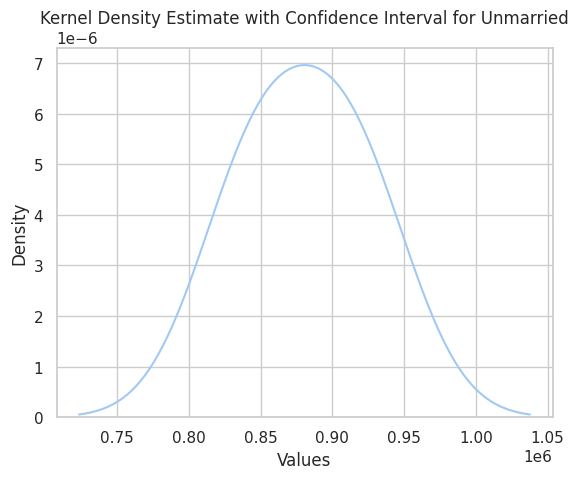

In [ ]:
# Calculate the confidence interval for Unmarried and presenting it on the graph
Unmarried_confidence_interval = (Unmarried_sample_mean - margin_of_error, Unmarried_sample_mean + margin_of_error)
print("Confidence Interval 95% Unmarried:", Unmarried_confidence_interval)
sns.kdeplot(Unmarried_confidence_interval)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Kernel Density Estimate with Confidence Interval for Unmarried')
plt.show()

Confidence Interval 95% Married: (810056.2692916514, 876997.3307083487)


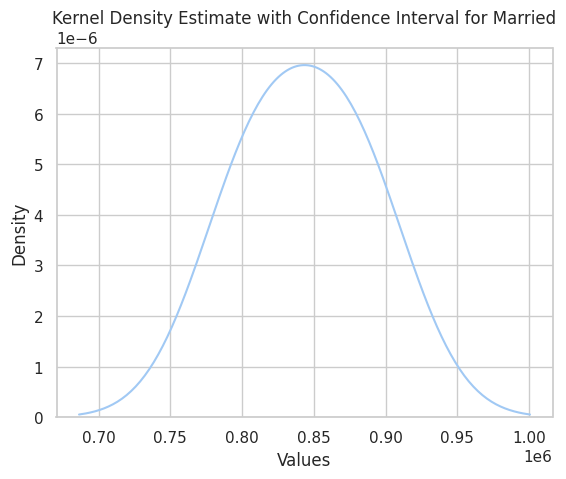

In [ ]:
# Calculate the confidence interval for female and presenting it on the graph
Married_confidence_interval = (Married_sample_mean - margin_of_error, Married_sample_mean + margin_of_error)
print("Confidence Interval 95% Married:", Married_confidence_interval)
sns.kdeplot(Married_confidence_interval)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Kernel Density Estimate with Confidence Interval for Married')
plt.show()

Insight:

1) With reference to the above data, at a 95% confidence interval:

a) The average amount spent by an unmarried customer will lie between 847105.2492916514 and 914046.3107083486.

b) The average amount spent by a married customer will lie between 810056.2692916514 and 876997.3307083487.

2) Confidence intervals for average unmarried and married spending are overlapping.

3) With respect to the above data, company should target more unmarried customers, as they spend a lot compared to married customers.

5. Results when the same activity is performed for Age

In [ ]:
def calculate_age_group_means_and_confidence_intervals(df):
    sum_by_age = df.groupby(['User_ID', 'Age'])['Purchase'].sum().reset_index()
    sum_by_age = sum_by_age.sort_values(by='User_ID', ascending=False)
    # Create dict and filtering data age group wise
    age_groups = {
        'Age_0_17': sum_by_age[sum_by_age['Age'] == '0-17'],
        'Age_18_25': sum_by_age[sum_by_age['Age'] == '18-25'],
        'Age_26_35': sum_by_age[sum_by_age['Age'] == '26-35'],
        'Age_36_45': sum_by_age[sum_by_age['Age'] == '36-45'],
        'Age_46_50': sum_by_age[sum_by_age['Age'] == '46-50'],
        'Age_51_55': sum_by_age[sum_by_age['Age'] == '51-55'],
        'Age_55+': sum_by_age[sum_by_age['Age'] == '55+']
    }
    # Define sample sizes and number of repetitions
    sample_sizes = {
        'Age_0_17': 200,
        'Age_18_25': 1000,
        'Age_26_35': 2000,
        'Age_36_45': 1000,
        'Age_46_50': 500,
        'Age_51_55': 400,
        'Age_55+': 300
    }
    num_repitions = 1000
    # Create a dictionary to store results
    results = {}
    # Perform random sampling and calculate means for each age group
    for age_group, age_df in age_groups.items():
        sample_size = sample_sizes.get(age_group, 0)
        sample_means = []
        for _ in range(num_repitions):
            random_sample = age_df.sample(n=sample_size)
            sample_mean = random_sample['Purchase'].mean()
            sample_means.append(sample_mean)
        # Calculate the population mean, sample mean, and standard deviation
        population_mean = age_df['Purchase'].mean()
        sample_mean_mean = sum(sample_means) / len(sample_means)
        sample_mean_std = pd.Series(sample_means).std()
        # Calculate the confidence interval using the z-distribution
        confidence_level = 0.95  # 95% confidence interval
        z_critical = stats.norm.ppf((1 + confidence_level) / 2)  # Z-score for the desired confidence level
        margin_of_error = z_critical * (age_df['Purchase'].std() / np.sqrt(sample_size))
        lower_bound = sample_mean_mean - margin_of_error
        upper_bound = sample_mean_mean + margin_of_error
        results[age_group] = {
            'Population Mean': population_mean,
            'Sample Mean Mean': sample_mean_mean,
            'Sample Mean Std': sample_mean_std,
            'Confidence Interval': (lower_bound, upper_bound)
        }
    return results
results = calculate_age_group_means_and_confidence_intervals(df)
for age_group, metrics in results.items():
    print(f'{age_group} average spent value, random mean value, std value and Confidence Interval:')
    print(f'{age_group} customer average spent amount: {metrics["Population Mean"]}')
    print(f'Random Sample Mean : {metrics["Sample Mean Mean"]}')
    print(f'Sample Mean Std: {metrics["Sample Mean Std"]}')
    print(f'Confidence Interval: {metrics["Confidence Interval"]}')
    print()

Age_0_17 average spent value, random mean value, std value and Confidence Interval:
Age_0_17 customer average spent amount: 618867.8119266055
Random Sample Mean : 618934.3784650007
Sample Mean Std: 13845.318504246638
Confidence Interval: (523714.94180939643, 714153.8151206048)

Age_18_25 average spent value, random mean value, std value and Confidence Interval:
Age_18_25 customer average spent amount: 854863.119738073
Random Sample Mean : 854837.2874919993
Sample Mean Std: 7137.833791937486
Confidence Interval: (799802.1381184596, 909872.436865539)

Age_26_35 average spent value, random mean value, std value and Confidence Interval:
Age_26_35 customer average spent amount: 989659.3170969313
Random Sample Mean : 989599.3107510011
Sample Mean Std: 3746.1285568842236
Confidence Interval: (944387.8344210777, 1034810.7870809245)

Age_36_45 average spent value, random mean value, std value and Confidence Interval:
Age_36_45 customer average spent amount: 879665.7103684661
Random Sample Mean 

Insights:

1) With reference to the above data, at a 95% confidence interval:

a) The highest average amount spent by 26- to 35-year-old customers will lie between 944419.9990 and 1034842.9516.

b) The average amount spent by 36- to 45-year-old customers will lie between 819003.0902 and 940678.8198.

c) The average amount spent by 18- to 25-year-old customers will lie between 799594.4375 and 909664.7362.

d) The average amount spent by 46- to 50-year-old customers will lie between 711215.1004 and 874125.3830.

e) The average amount spent by 51- to 55-year-old customers will lie between 685670.0292 and 840962.3353.

f) The average amount spent by 55+ age group customers will lie between 470454.5225 and 610200.5797.

g) The lowest average amount spent by 0 to 17-year-old customers will lie between 524534.4423 and 714973.3156.

2) From the above data, it is clear that the age group 26 to 35 spends more compared to other age categories.

3) Age groups above 55 and below 0 to 17 spend very little compared to others.

4) Confidence intervals for average 26- to 35-year-old and 36- to 45-year-old spending are not overlapping.

5) With respect to the above data, the company should target the age category between 26 and 35, as they spend more money compared to others.

### 5. Insights:

Spending Behavior by Gender:

1. Men tend to spend slightly more per transaction than women, indicating potential differences in purchasing habits.

2. The customer base is predominantly male, suggesting a potential bias and the need to understand the reasons behind this imbalance.

3. Purchase amount distributions for both genders are right-skewed, with most purchases being smaller and fewer high-value transactions.

4. While men spend slightly more per transaction, female customers might be more frequent buyers, leading to slightly higher total spending per female customer.


Distribution of Sample Means:


5. Histograms of sample means for both genders show a normal distribution, suggesting reliable sampling and a good representation of overall spending behavior.

6. The confidence interval for average male spending is narrow, indicating high certainty about the estimated average.

7. The confidence interval for average female spending is also relatively narrow, but less symmetrical than for males, suggesting a wider range of spending behavior among female customers.

Confidence Intervals and Business Implications:

8. At a 95% confidence interval, the average amount spent by male customers is estimated to be between 896453.54 and 954235.25.

9. At a 95% confidence interval, the average amount spent by female customers is estimated to be between 683133.53 and 740915.24.

10. The confidence intervals for average male and female spending do not overlap, suggesting a significant difference in spending behavior.

11. Based on this analysis, targeting male customers might yield higher returns due to their higher average spending.

Spending Behavior by Marital Status:

12. Unmarried customers, on average, spend more than married customers.

13. At a 95% confidence interval, the average amount spent by unmarried customers is estimated to be between 847105.25 and 914046.31.

14. At a 95% confidence interval, the average amount spent by married customers is estimated to be between 810056.27 and 876997.33.

15. The confidence intervals for average unmarried and married spending overlap, suggesting less pronounced differences in spending behavior compared to gender.

16. Despite the overlap, targeting unmarried customers might still be more beneficial due to their slightly higher average spending.

Spending Behavior by Age:

17. The age group 26-35 exhibits the highest average spending, followed by 36-45 and 18-25.

18. Age groups above 55 and below 17 show significantly lower average spending compared to other age categories.

19. At a 95% confidence interval, the average amount spent by 26-35 year olds is estimated to be between 944419.99 and 1034842.95.

20. At a 95% confidence interval, the average amount spent by 36-45 year olds is estimated to be between 819003.09 and 940678.82.

21. The confidence intervals for average spending by 26-35 and 36-45 year olds do not overlap, indicating a significant difference.

22. Targeting the 26-35 age group is likely to yield the highest returns due to their significantly higher average spending.

General Recommendations:

23. Consider developing targeted marketing campaigns for male and unmarried customers, as they exhibit higher average spending.

24. Focus marketing efforts on the 26-35 age group, as they are the most significant spenders.

25. Explore potential reasons for the underrepresentation of female customers and develop strategies to attract and retain them.

26. Investigate the reasons behind lower spending in older (55+) and younger (0-17) age groups and tailor marketing approaches accordingly.

27. Analyze spending patterns within each age and gender group to identify further opportunities for personalized marketing.

28. Continuously monitor and analyze spending behavior to adapt marketing strategies to evolving trends and customer preferences.

29. Consider offering loyalty programs or discounts to incentivize repeat purchases, especially among female customers.

30. Conduct further research to understand the underlying factors driving spending behavior across different demographics.


### 6. Recommendations

1) Men spend more money than women, so the company should focus on retaining male customers and getting more male customers.

2) Product Category: 5, 1, and 8 have the highest purchasing frequency. It means the products in these categories are liked more by customers. The company can focus on selling more of these products.

3) Product Category: 11, 2, and 6, 3 have almost close competition in purchasing. The company can focus on selling more of these products.

4) Unmarried customers spend more money compared to married customers. So the company should focus on retaining the unmarried customers and getting more unmarried customers.

5) 86% of purchases are done by customers whose ages are between 18 and 45. So the company should focus on the acquisition of customers who are aged 18–45.

6) Customers living in City_Category C spend more money than other customers living in B or A. Selling more products in City Category C will help the company increase sales.


Customer Segmentation and Targeting:

1. **Focus on High-Value Male Customers:** Develop targeted marketing campaigns and loyalty programs specifically tailored to male customers, considering their higher average spending.

2. **Engage Female Customers with Frequency-Based Incentives:** Implement strategies to encourage more frequent purchases from female customers, such as loyalty points or exclusive discounts for repeat buyers.

3. **Personalize Offers for Unmarried Customers:** Leverage data on marital status to create personalized promotions and product recommendations that resonate with the spending habits of unmarried customers.

4. **Target Age Group 26-35 with Premium Products:** Introduce premium product lines or exclusive experiences aimed at the 26-35 age group, who exhibit the highest average spending.

5. **Develop Age-Specific Marketing Strategies:** Tailor marketing messages and channels to different age groups, considering their varying spending patterns and preferences.

Product and Inventory Management:

6. **Prioritize Product Categories 5, 1, and 8:** Ensure sufficient inventory and prominent placement for products in these high-demand categories.

7. **Boost Sales for Categories 11, 2, 6, and 3:** Implement promotional activities or bundle offers to increase sales for products in these competitive categories.

8. **Analyze Low-Performing Product Categories:** Investigate reasons for low sales in specific categories and consider adjustments to pricing, marketing, or product offerings.

9. **Optimize Inventory Management:** Utilize data on purchase frequency and seasonality to optimize inventory levels and minimize stockouts or overstocking.

Geographic and Channel Optimization:

10. **Expand Presence in City Category C:** Explore opportunities to increase market share in City Category C, where customers demonstrate higher spending.

11. **Tailor Marketing to City-Specific Preferences:** Analyze spending patterns in different cities to customize marketing messages and product offerings.

12. **Invest in Online Channels:** Given the convenience and reach of online platforms, allocate resources to enhance the online shopping experience and attract a wider customer base.

13. **Enhance Customer Experience:**

14. **Improve Customer Service:** Invest in training and resources to provide exceptional customer service across all touchpoints.

15. **Personalize Recommendations:** Utilize data on past purchases and browsing behavior to offer personalized product recommendations to individual customers.

16. **Loyalty Programs:** Implement a robust loyalty program to reward repeat customers and incentivize continued engagement.

Data-Driven Decision Making:

17. **Continuous Data Analysis:** Establish a system for ongoing data collection and analysis to monitor trends, identify opportunities, and adapt strategies accordingly.

18. **A/B Testing:** Conduct A/B tests to evaluate the effectiveness of different marketing campaigns, product placements, and pricing strategies.

19. **Customer Feedback:** Actively collect and analyze customer feedback to identify areas for improvement and enhance the overall shopping experience.

20. **Cross-Functional Collaboration:** Foster collaboration between marketing, sales, inventory management, and customer service teams to leverage data insights and drive business growth.


